In [225]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt
plt.style.use("ggplot")

In [226]:
df = pd.read_csv("../data/beverage_distribution_data.csv")

df["date"] = pd.to_datetime(df["date"])

In [227]:
df.head

<bound method NDFrame.head of            date  week_number sku_id     sku_name       category warehouse_id  \
0    2024-01-07            1  SKU01  Lager 650ml           Beer         WH01   
1    2024-01-14            2  SKU01  Lager 650ml           Beer         WH01   
2    2024-01-21            3  SKU01  Lager 650ml           Beer         WH01   
3    2024-01-28            4  SKU01  Lager 650ml           Beer         WH01   
4    2024-02-04            5  SKU01  Lager 650ml           Beer         WH01   
...         ...          ...    ...          ...            ...          ...   
4987 2025-11-30          100  SKU12  Cider 500ml  Non-Alcoholic         WH04   
4988 2025-12-07          101  SKU12  Cider 500ml  Non-Alcoholic         WH04   
4989 2025-12-14          102  SKU12  Cider 500ml  Non-Alcoholic         WH04   
4990 2025-12-21          103  SKU12  Cider 500ml  Non-Alcoholic         WH04   
4991 2025-12-28          104  SKU12  Cider 500ml  Non-Alcoholic         WH04   

     ware

In [228]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4992 entries, 0 to 4991
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date                   4992 non-null   datetime64[ns]
 1   week_number            4992 non-null   int64         
 2   sku_id                 4992 non-null   object        
 3   sku_name               4992 non-null   object        
 4   category               4992 non-null   object        
 5   warehouse_id           4992 non-null   object        
 6   warehouse_name         4992 non-null   object        
 7   unit_price             4992 non-null   int64         
 8   lead_time_days         4992 non-null   int64         
 9   festival_flag          4992 non-null   int64         
 10  promo_flag             4992 non-null   int64         
 11  demand_units           4992 non-null   int64         
 12  available_stock_units  4992 non-null   int64         
 13  ful

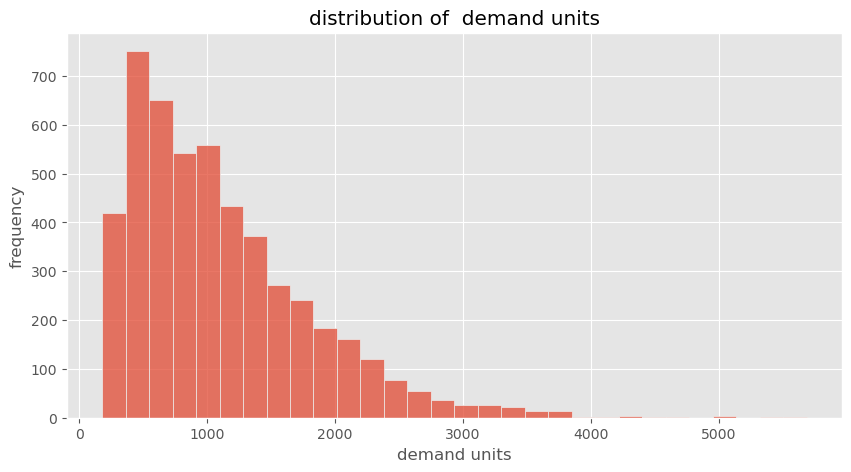

In [229]:
#how is demand distributed 
plt.figure(figsize=(10,5))
sns.histplot(df['demand_units'],bins=30)
plt.title('distribution of  demand units')
plt.xlabel('demand units')
plt.ylabel('frequency')
plt.show()

In [230]:
## Demand is not perfectly uniform. 
'''Most observations lie within the middle range, while a few high-demand periods indicate peak sales.
This suggests demand variability, 
which is common in FMCG supply chains due to promotions and seasonal events.'''

'Most observations lie within the middle range, while a few high-demand periods indicate peak sales.\nThis suggests demand variability, \nwhich is common in FMCG supply chains due to promotions and seasonal events.'

In [231]:
# which warehouse serves the most customer demand
warehouse_demand = (df.groupby("warehouse_name")['demand_units']
                               .sum()
                               .sort_values(ascending=False)
                   )
warehouse_demand

warehouse_name
West DC     1769897
North DC    1567765
South DC    1212700
East DC     1019963
Name: demand_units, dtype: int64

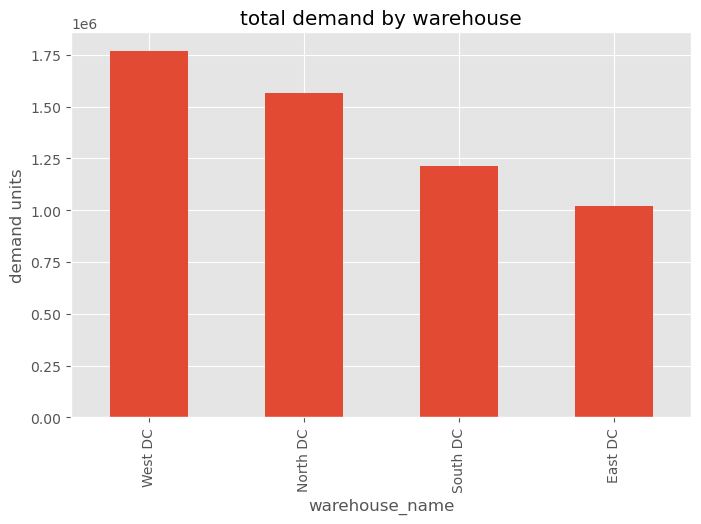

In [232]:
plt.figure(figsize=(8,5))
warehouse_demand.plot(kind='bar')
plt.title('total demand by warehouse')
plt.ylabel('demand units')
plt.show()

In [233]:
## Warehouse West DC records the highest total demand and therefore requires higher inventory availability
#to maintain service levels.

In [234]:
#q which produnts sell the most 
sku_demand = (
    df.groupby("sku_name")["demand_units"]
    .sum()
    .sort_values(ascending=False)
)
sku_demand

sku_name
Lager 330ml            815994
Lager 650ml            815349
Lager Can 500ml        808656
Light Beer 330ml       465515
Strong Beer 650ml      464037
Premium Lager 500ml    462767
Malt Drink 300ml       461986
Premium Can 330ml      461337
Wheat Beer 650ml       204138
Soda Mixer 250ml       203810
Craft IPA 330ml        203571
Cider 500ml            203165
Name: demand_units, dtype: int64

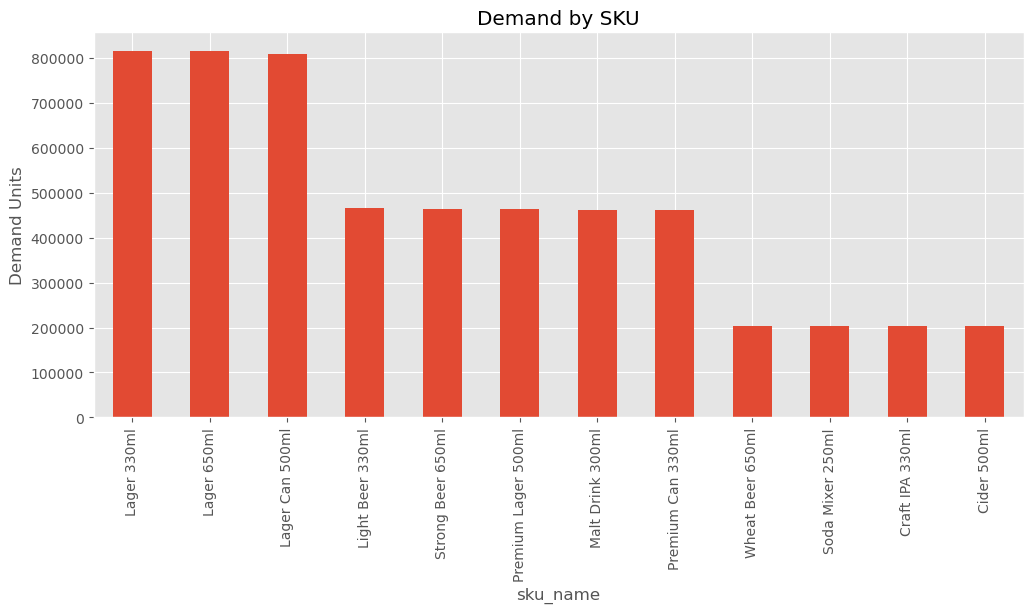

In [235]:
plt.figure(figsize=(12,5))

sku_demand.plot(kind="bar")

plt.title("Demand by SKU")

plt.ylabel("Demand Units")

plt.show()

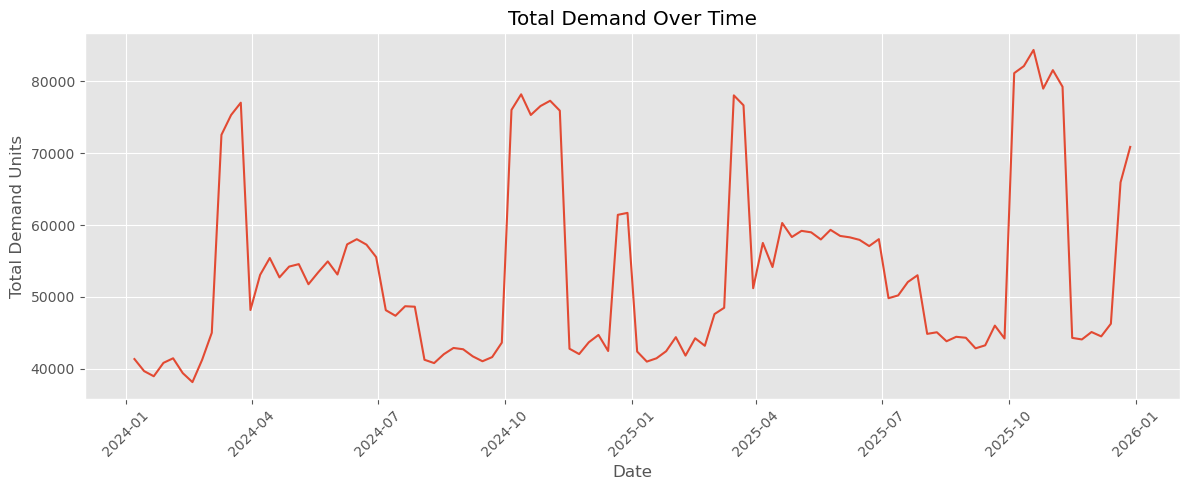

In [236]:
weekly_demand = (
    df.groupby("date")["demand_units"]
      .sum()
      .reset_index()
)

plt.figure(figsize=(12,5))

plt.plot(
    weekly_demand["date"],
    weekly_demand["demand_units"]
)

plt.title("Total Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Total Demand Units")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation

Total demand shows substantial variation over time, with several recurring peaks and lower-demand periods. The pattern suggests that demand is influenced by time-dependent factors rather than remaining constant throughout the year.

The repeated demand spikes indicate potential seasonality or event-driven effects. Festival and promotion flags will be analyzed separately to determine whether these factors are associated with higher demand.

In [237]:
festival_demand = (
    df.groupby("festival_flag")["demand_units"]
      .mean()
)

festival_demand

festival_flag
0     999.934990
1    1573.992063
Name: demand_units, dtype: float64

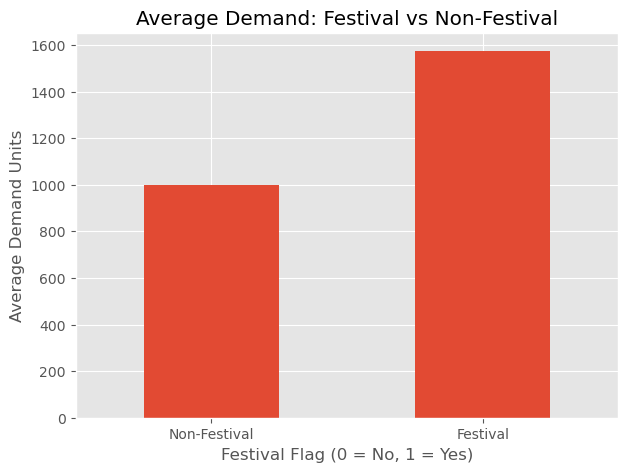

In [238]:
plt.figure(figsize=(7,5))
festival_demand.plot(kind='bar')
plt.title("Average Demand: Festival vs Non-Festival")
plt.xlabel("Festival Flag (0 = No, 1 = Yes)")
plt.ylabel("Average Demand Units")

plt.xticks(
    ticks=[0, 1],
    labels=["Non-Festival", "Festival"],
    rotation=0
)

plt.show()


### Festival Demand Analysis

Average demand is approximately 1,000 units during non-festival periods compared with approximately 1,574 units during festival-flagged periods.

The simulated data therefore shows a strong association between festival periods and increased demand. This indicates that festival-related features may be useful predictors for demand forecasting and inventory planning.

Since the dataset is synthetic, this result should be interpreted as a pattern within the simulation rather than a real-world market estimate.

In [239]:
promo_demand = (
    df.groupby("promo_flag")["demand_units"]
      .mean()
)

promo_demand

promo_flag
0    1090.289468
1    1390.524706
Name: demand_units, dtype: float64

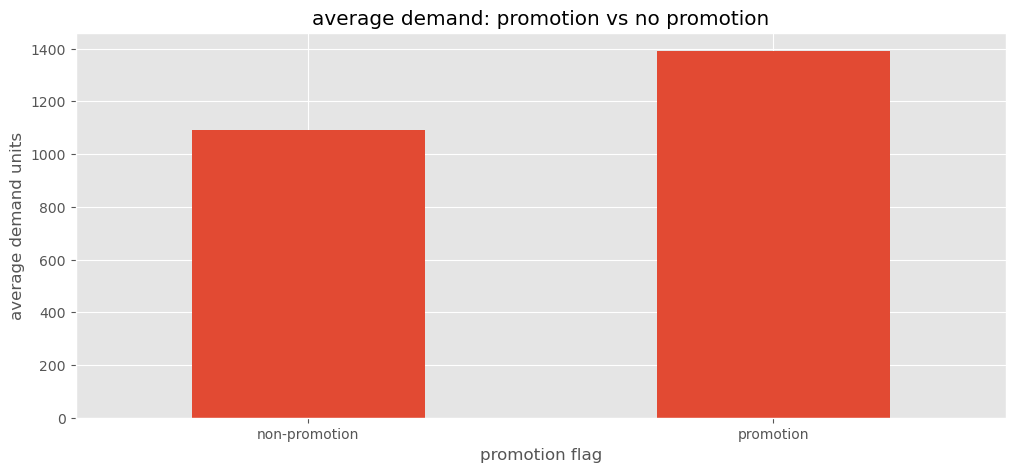

In [240]:
plt.figure(figsize=(12,5))
promo_demand.plot(kind='bar')
plt.title('average demand: promotion vs no promotion')
plt.xlabel('promotion flag')
plt.ylabel('average demand units')

plt.xticks(
    ticks=[0,1],
    labels=['non-promotion', 'promotion'],
    rotation=0
    )
plt.show()

### Promotion Demand Analysis

Average demand during promotion periods is approximately 1,391 units compared with approximately 1,090 units during non-promotion periods.

The simulated dataset therefore shows an association between promotional periods and higher demand. The promotion flag can potentially provide useful information for demand forecasting and inventory planning.

Since the dataset is synthetic, this result represents a pattern within the simulation and should not be interpreted as a real-world causal estimate.

In [241]:
stockout_summary = df["stockout_flag"].value_counts()

stockout_summary


stockout_flag
0    4141
1     851
Name: count, dtype: int64

In [242]:
stockout_rate = df["stockout_flag"].mean() * 100

print(f"Overall stockout rate: {stockout_rate:.2f}%")

Overall stockout rate: 17.05%


In [243]:
stockout_by_warehouse = (
    df.groupby("warehouse_name")["stockout_flag"]
      .sum()
      .sort_values(ascending=False)
)

stockout_by_warehouse

warehouse_name
North DC    235
West DC     207
South DC    206
East DC     203
Name: stockout_flag, dtype: int64

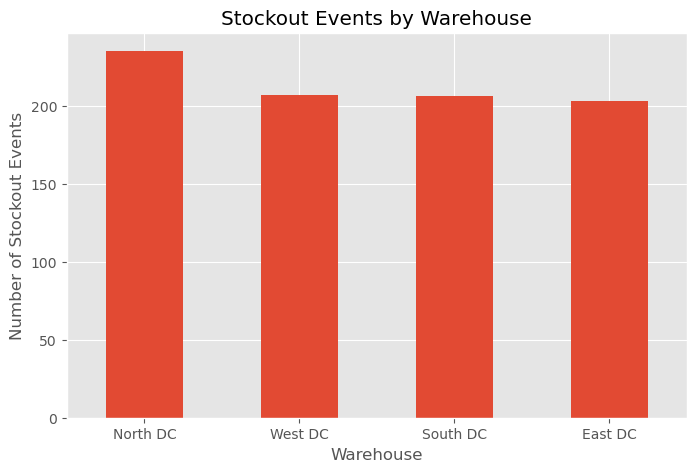

In [244]:
plt.figure(figsize=(8,5))

stockout_by_warehouse.plot(kind="bar")

plt.title("Stockout Events by Warehouse")
plt.xlabel("Warehouse")
plt.ylabel("Number of Stockout Events")

plt.xticks(rotation=0)

plt.show()

### Stockout Analysis by Warehouse

North DC records the highest number of stockout events (235), followed by West DC (207), South DC (206), and East DC (203).

The differences are relatively small, suggesting that stockout risk is distributed across the network rather than concentrated in a single warehouse.

However, stockout counts alone do not account for differences in the number of observations per warehouse. Warehouse-level stockout rates will therefore provide a more meaningful comparison.

In [245]:
stockout_rate_warehouse = (
    df.groupby("warehouse_name")["stockout_flag"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

stockout_rate_warehouse

warehouse_name
North DC    18.830128
West DC     16.586538
South DC    16.506410
East DC     16.266026
Name: stockout_flag, dtype: float64

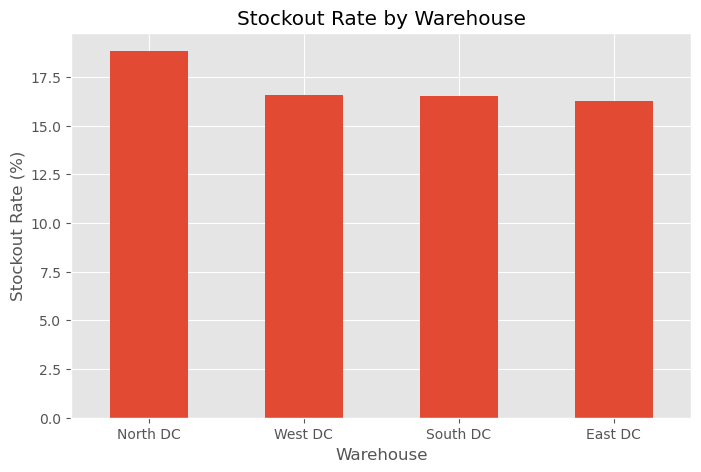

In [246]:
plt.figure(figsize=(8,5))

stockout_rate_warehouse.plot(kind="bar")

plt.title("Stockout Rate by Warehouse")
plt.xlabel("Warehouse")
plt.ylabel("Stockout Rate (%)")

plt.xticks(rotation=0)

plt.show()

### Stockout Rate by Warehouse

North DC has the highest stockout rate at 18.83%, followed by West DC (16.59%), South DC (16.50%), and East DC (16.27%).

Although North DC has the highest stockout rate, the relatively small difference across warehouses suggests that stockout risk is distributed across the network rather than being isolated to one warehouse.

Warehouse-level stockout rates provide a more meaningful comparison than raw stockout counts because they account for differences in the number of observations.

In [247]:
stockout_by_sku = (
    df.groupby("sku_name")["stockout_flag"]
      .sum()
      .sort_values(ascending=False)
)

stockout_by_sku

sku_name
Lager 650ml            90
Strong Beer 650ml      79
Cider 500ml            75
Wheat Beer 650ml       73
Premium Can 330ml      72
Craft IPA 330ml        72
Soda Mixer 250ml       72
Lager Can 500ml        70
Lager 330ml            65
Light Beer 330ml       65
Premium Lager 500ml    62
Malt Drink 300ml       56
Name: stockout_flag, dtype: int64

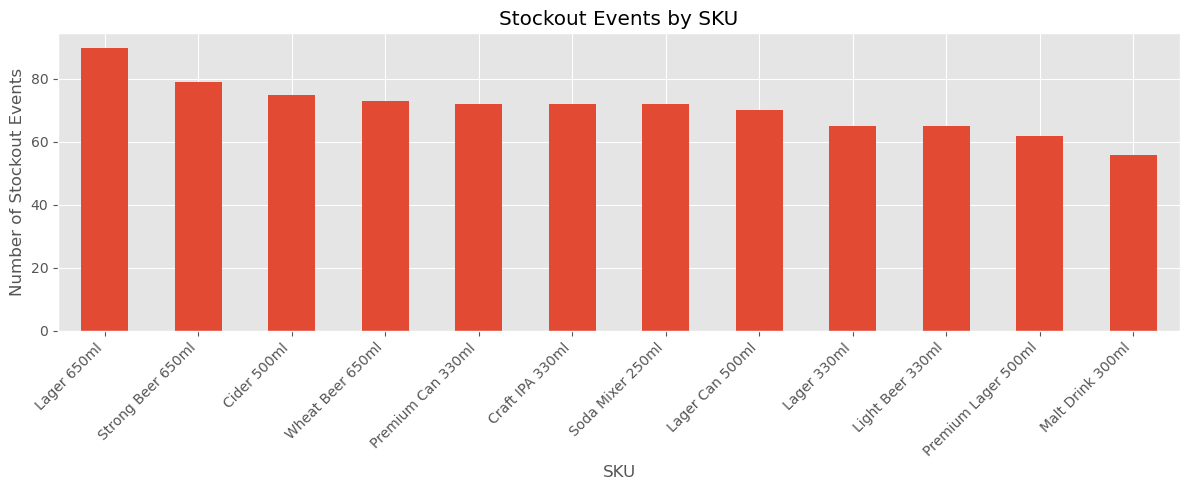

In [248]:
plt.figure(figsize=(12,5))

stockout_by_sku.plot(kind="bar")

plt.title("Stockout Events by SKU")
plt.xlabel("SKU")
plt.ylabel("Number of Stockout Events")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### Stockout Analysis by SKU

Lager 650ml records the highest number of stockout events (90), followed by Strong Beer 650ml (79) and Cider 500ml (75).

Stockout events are distributed across multiple SKUs rather than being concentrated in a single product. This suggests that inventory availability should be evaluated across the product portfolio rather than focusing only on one SKU.

Further analysis will compare demand and stockout patterns to identify products that may require greater inventory attention.

In [249]:
# QUESTION: Are the products with higher demand also experiencing more stockouts?
sku_analysis = (
    df.groupby("sku_name")
      .agg(
          total_demand=("demand_units", "sum"),
          stockout_events=("stockout_flag", "sum")
      )
      .sort_values("total_demand", ascending=False)
)

sku_analysis

,total_demand,stockout_events
sku_name,,
Lager 330ml,815994,65
Lager 650ml,815349,90
Lager Can 500ml,808656,70
Light Beer 330ml,465515,65
Strong Beer 650ml,464037,79
Premium Lager 500ml,462767,62
Malt Drink 300ml,461986,56
Premium Can 330ml,461337,72
Wheat Beer 650ml,204138,73


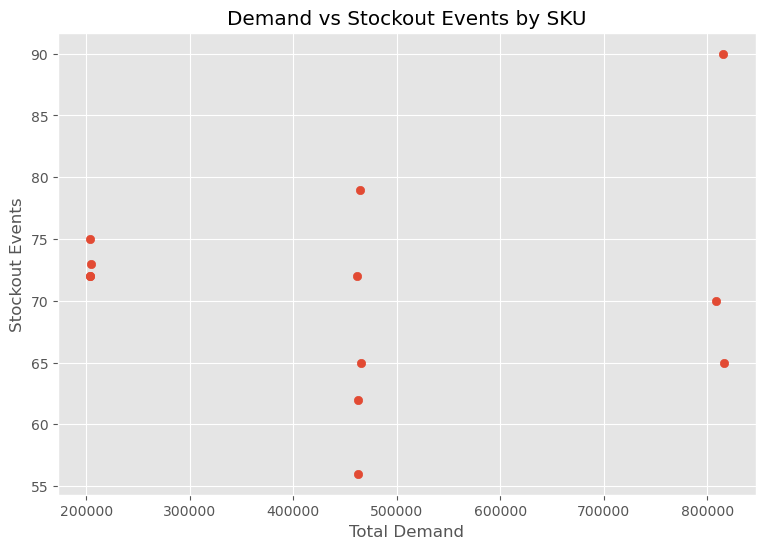

In [250]:
plt.figure(figsize=(9,6))

plt.scatter(
    sku_analysis["total_demand"],
    sku_analysis["stockout_events"]
)

plt.xlabel("Total Demand")
plt.ylabel("Stockout Events")
plt.title("Demand vs Stockout Events by SKU")

plt.show()

### Demand vs Stockout Analysis

The analysis shows that stockout frequency is not determined by demand alone. While some high-demand SKUs such as Lager 650ml experience frequent stockouts, several lower-demand SKUs also record a relatively high number of stockout events.

For example, Cider 500ml has substantially lower total demand than Lager 330ml but records more stockout events.

This suggests that factors beyond demand, such as inventory availability, lead time, promotions, festivals, and inventory policies, may contribute to stockout risk. These factors will therefore be considered in subsequent analysis and forecasting.

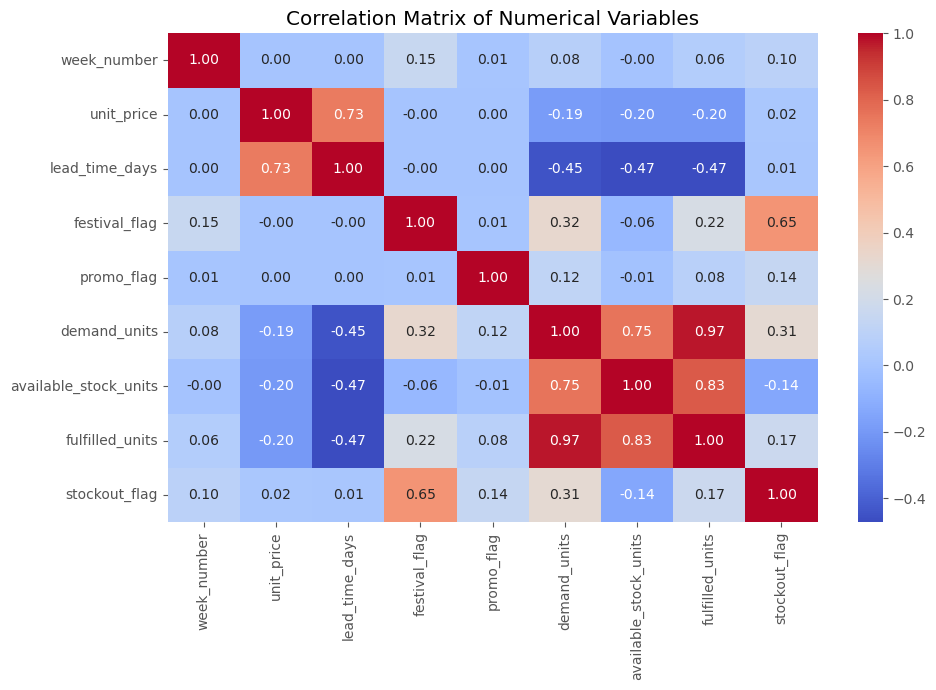

In [251]:
plt.figure(figsize=(10,7))

corr = df.select_dtypes(include="number").corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

| Relationship                      | Correlation | Interpretation       |
| --------------------------------- | ----------: | -------------------- |
| Demand ↔ Fulfilled Units          |    **0.97** | Very strong positive |
| Available Stock ↔ Fulfilled Units |    **0.83** | Strong positive      |
| Demand ↔ Available Stock          |    **0.75** | Strong positive      |
| Unit Price ↔ Lead Time            |    **0.73** | Strong positive      |
| Festival ↔ Stockout               |    **0.65** | Strong positive      |
| Lead Time ↔ Available Stock       |   **-0.47** | Moderate negative    |

    ### Correlation Analysis

The correlation matrix highlights several important relationships within the dataset. 
Demand has a strong positive correlation with fulfilled units (0.97) and available stock (0.75), 
    while available stock and fulfilled units also show a strong positive relationship (0.83).

Festival flag shows a relatively strong positive correlation with stockout flag (0.65), 
supporting the earlier observation that festival periods are associated with higher stockout risk.

Lead time has moderate negative correlations with available stock (-0.47) and fulfilled units (-0.47), 
suggesting that longer replenishment times are associated with lower inventory availability and fulfilment.

Demand has only a moderate correlation with stockout flag (0.31), indicating that demand alone does not fully explain stockout risk.
Multiple operational and demand-related factors should therefore be considered in subsequent analysis.

In [252]:
# Time-based features

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["quarter"] = df["date"].dt.quarter
df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)

df.head()

,date,week_number,sku_id,sku_name,category,warehouse_id,warehouse_name,unit_price,lead_time_days,festival_flag,promo_flag,demand_units,available_stock_units,fulfilled_units,stockout_flag,year,month,quarter,week_of_year
0,2024-01-07,1,SKU01,Lager 650ml,Beer,WH01,North DC,120,5,0,0,1395,2254,1395,0,2024,1,1,1
1,2024-01-14,2,SKU01,Lager 650ml,Beer,WH01,North DC,120,5,0,0,1674,3435,1674,0,2024,1,1,2
2,2024-01-21,3,SKU01,Lager 650ml,Beer,WH01,North DC,120,5,0,1,2085,4337,2085,0,2024,1,1,3
3,2024-01-28,4,SKU01,Lager 650ml,Beer,WH01,North DC,120,5,0,0,1812,2252,1812,0,2024,1,1,4
4,2024-02-04,5,SKU01,Lager 650ml,Beer,WH01,North DC,120,5,0,1,1881,3016,1881,0,2024,2,1,5


In [253]:
df = df.sort_values(["sku_name", "warehouse_name", "date"]).reset_index(drop=True)

In [254]:
df["demand_lag_1"] = (
    df.groupby(["sku_name", "warehouse_name"])["demand_units"]
      .shift(1)
)

df["demand_lag_2"] = (
    df.groupby(["sku_name", "warehouse_name"])["demand_units"]
      .shift(2)
)

df["demand_lag_4"] = (
    df.groupby(["sku_name", "warehouse_name"])["demand_units"]
      .shift(4)
)

In [255]:
df["rolling_demand_4w"] = (
    df.groupby(["sku_name", "warehouse_name"])["demand_units"]
      .transform(lambda x: x.shift(1).rolling(4).mean())
)

In [256]:
df["demand_std_4w"] = (
    df.groupby(["sku_name", "warehouse_name"])["demand_units"]
      .transform(lambda x: x.shift(1).rolling(4).std())
)

In [257]:
df["inventory_coverage"] = (
    df["available_stock_units"] / df["rolling_demand_4w"]
)

In [258]:
df["fulfillment_rate"] = (
    df["fulfilled_units"] / df["demand_units"]
)

In [259]:
df[
    [
        "date",
        "sku_name",
        "warehouse_name",
        "demand_units",
        "demand_lag_1",
        "demand_lag_2",
        "demand_lag_4",
        "rolling_demand_4w",
        "demand_std_4w",
        "inventory_coverage",
        "fulfillment_rate"
    ]
].head(15)

,date,sku_name,warehouse_name,demand_units,demand_lag_1,demand_lag_2,demand_lag_4,rolling_demand_4w,demand_std_4w,inventory_coverage,fulfillment_rate
0,2024-01-07,Cider 500ml,East DC,246,NaN,NaN,NaN,NaN,NaN,NaN,1.000000
1,2024-01-14,Cider 500ml,East DC,224,246.0,NaN,NaN,NaN,NaN,NaN,1.000000
2,2024-01-21,Cider 500ml,East DC,360,224.0,246.0,NaN,NaN,NaN,NaN,0.883333
3,2024-01-28,Cider 500ml,East DC,280,360.0,224.0,NaN,NaN,NaN,NaN,1.000000
4,2024-02-04,Cider 500ml,East DC,277,280.0,360.0,246.0,277.50,59.629411,2.018018,1.000000
5,2024-02-11,Cider 500ml,East DC,281,277.0,280.0,224.0,285.25,56.079557,2.464505,1.000000
6,2024-02-18,Cider 500ml,East DC,285,281.0,277.0,360.0,299.50,40.369130,1.409015,1.000000
7,2024-02-25,Cider 500ml,East DC,324,285.0,281.0,280.0,280.75,3.304038,1.983972,1.000000
8,2024-03-03,Cider 500ml,East DC,316,324.0,285.0,277.0,291.75,21.746647,2.238218,1.000000
9,2024-03-10,Cider 500ml,East DC,525,316.0,324.0,281.0,301.50,21.671794,1.117745,0.641905


In [260]:
df["unfulfilled_units"] = (
    df["demand_units"] - df["fulfilled_units"]
)

In [261]:
df["inventory_gap"] = (
    df["available_stock_units"] - df["demand_units"]
)





In [262]:
df[
    [
        "demand_units",
        "available_stock_units",
        "fulfilled_units",
        "inventory_coverage",
        "fulfillment_rate",
        "unfulfilled_units",
        "inventory_gap"
    ]
].head(10)

,demand_units,available_stock_units,fulfilled_units,inventory_coverage,fulfillment_rate,unfulfilled_units,inventory_gap
0,246,368,246,NaN,1.000000,0,122
1,224,542,224,NaN,1.000000,0,318
2,360,318,318,NaN,0.883333,42,-42
3,280,420,280,NaN,1.000000,0,140
4,277,560,277,2.018018,1.000000,0,283
5,281,703,281,2.464505,1.000000,0,422
6,285,422,285,1.409015,1.000000,0,137
7,324,557,324,1.983972,1.000000,0,233
8,316,653,316,2.238218,1.000000,0,337
9,525,337,337,1.117745,0.641905,188,-188


In [263]:
df.shape


(4992, 28)

In [264]:
df.columns.tolist()

['date',
 'week_number',
 'sku_id',
 'sku_name',
 'category',
 'warehouse_id',
 'warehouse_name',
 'unit_price',
 'lead_time_days',
 'festival_flag',
 'promo_flag',
 'demand_units',
 'available_stock_units',
 'fulfilled_units',
 'stockout_flag',
 'year',
 'month',
 'quarter',
 'week_of_year',
 'demand_lag_1',
 'demand_lag_2',
 'demand_lag_4',
 'rolling_demand_4w',
 'demand_std_4w',
 'inventory_coverage',
 'fulfillment_rate',
 'unfulfilled_units',
 'inventory_gap']

In [265]:
df["target_demand"] = (
    df.groupby(["sku_name", "warehouse_name"])["demand_units"]
      .shift(-1)
)

In [266]:
df[
    [
        "date",
        "sku_name",
        "warehouse_name",
        "demand_units",
        "target_demand"
    ]
].head(10)

,date,sku_name,warehouse_name,demand_units,target_demand
0,2024-01-07,Cider 500ml,East DC,246,224.0
1,2024-01-14,Cider 500ml,East DC,224,360.0
2,2024-01-21,Cider 500ml,East DC,360,280.0
3,2024-01-28,Cider 500ml,East DC,280,277.0
4,2024-02-04,Cider 500ml,East DC,277,281.0
5,2024-02-11,Cider 500ml,East DC,281,285.0
6,2024-02-18,Cider 500ml,East DC,285,324.0
7,2024-02-25,Cider 500ml,East DC,324,316.0
8,2024-03-03,Cider 500ml,East DC,316,525.0
9,2024-03-10,Cider 500ml,East DC,525,467.0


In [267]:
df["target_demand"].isna().sum()

np.int64(48)

In [268]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4992 entries, 0 to 4991
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date                   4992 non-null   datetime64[ns]
 1   week_number            4992 non-null   int64         
 2   sku_id                 4992 non-null   object        
 3   sku_name               4992 non-null   object        
 4   category               4992 non-null   object        
 5   warehouse_id           4992 non-null   object        
 6   warehouse_name         4992 non-null   object        
 7   unit_price             4992 non-null   int64         
 8   lead_time_days         4992 non-null   int64         
 9   festival_flag          4992 non-null   int64         
 10  promo_flag             4992 non-null   int64         
 11  demand_units           4992 non-null   int64         
 12  available_stock_units  4992 non-null   int64         
 13  ful

In [269]:
df_model = df.dropna(subset=["target_demand"]).copy()
df_model.shape


(4944, 29)

In [270]:
df.head(10)

,date,week_number,sku_id,sku_name,category,warehouse_id,warehouse_name,unit_price,lead_time_days,festival_flag,...,demand_lag_1,demand_lag_2,demand_lag_4,rolling_demand_4w,demand_std_4w,inventory_coverage,fulfillment_rate,unfulfilled_units,inventory_gap,target_demand
0,2024-01-07,1,SKU12,Cider 500ml,Non-Alcoholic,WH04,East DC,130,10,0,...,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0,122,224.0
1,2024-01-14,2,SKU12,Cider 500ml,Non-Alcoholic,WH04,East DC,130,10,0,...,246.0,NaN,NaN,NaN,NaN,NaN,1.000000,0,318,360.0
2,2024-01-21,3,SKU12,Cider 500ml,Non-Alcoholic,WH04,East DC,130,10,0,...,224.0,246.0,NaN,NaN,NaN,NaN,0.883333,42,-42,280.0
3,2024-01-28,4,SKU12,Cider 500ml,Non-Alcoholic,WH04,East DC,130,10,0,...,360.0,224.0,NaN,NaN,NaN,NaN,1.000000,0,140,277.0
4,2024-02-04,5,SKU12,Cider 500ml,Non-Alcoholic,WH04,East DC,130,10,0,...,280.0,360.0,246.0,277.50,59.629411,2.018018,1.000000,0,283,281.0
5,2024-02-11,6,SKU12,Cider 500ml,Non-Alcoholic,WH04,East DC,130,10,0,...,277.0,280.0,224.0,285.25,56.079557,2.464505,1.000000,0,422,285.0
6,2024-02-18,7,SKU12,Cider 500ml,Non-Alcoholic,WH04,East DC,130,10,0,...,281.0,277.0,360.0,299.50,40.369130,1.409015,1.000000,0,137,324.0
7,2024-02-25,8,SKU12,Cider 500ml,Non-Alcoholic,WH04,East DC,130,10,0,...,285.0,281.0,280.0,280.75,3.304038,1.983972,1.000000,0,233,316.0
8,2024-03-03,9,SKU12,Cider 500ml,Non-Alcoholic,WH04,East DC,130,10,0,...,324.0,285.0,277.0,291.75,21.746647,2.238218,1.000000,0,337,525.0
9,2024-03-10,10,SKU12,Cider 500ml,Non-Alcoholic,WH04,East DC,130,10,1,...,316.0,324.0,281.0,301.50,21.671794,1.117745,0.641905,188,-188,467.0


In [271]:
df_model['target_demand'].isna().sum()

np.int64(0)

In [272]:
df_model.head(10)

,date,week_number,sku_id,sku_name,category,warehouse_id,warehouse_name,unit_price,lead_time_days,festival_flag,...,demand_lag_1,demand_lag_2,demand_lag_4,rolling_demand_4w,demand_std_4w,inventory_coverage,fulfillment_rate,unfulfilled_units,inventory_gap,target_demand
0,2024-01-07,1,SKU12,Cider 500ml,Non-Alcoholic,WH04,East DC,130,10,0,...,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0,122,224.0
1,2024-01-14,2,SKU12,Cider 500ml,Non-Alcoholic,WH04,East DC,130,10,0,...,246.0,NaN,NaN,NaN,NaN,NaN,1.000000,0,318,360.0
2,2024-01-21,3,SKU12,Cider 500ml,Non-Alcoholic,WH04,East DC,130,10,0,...,224.0,246.0,NaN,NaN,NaN,NaN,0.883333,42,-42,280.0
3,2024-01-28,4,SKU12,Cider 500ml,Non-Alcoholic,WH04,East DC,130,10,0,...,360.0,224.0,NaN,NaN,NaN,NaN,1.000000,0,140,277.0
4,2024-02-04,5,SKU12,Cider 500ml,Non-Alcoholic,WH04,East DC,130,10,0,...,280.0,360.0,246.0,277.50,59.629411,2.018018,1.000000,0,283,281.0
5,2024-02-11,6,SKU12,Cider 500ml,Non-Alcoholic,WH04,East DC,130,10,0,...,277.0,280.0,224.0,285.25,56.079557,2.464505,1.000000,0,422,285.0
6,2024-02-18,7,SKU12,Cider 500ml,Non-Alcoholic,WH04,East DC,130,10,0,...,281.0,277.0,360.0,299.50,40.369130,1.409015,1.000000,0,137,324.0
7,2024-02-25,8,SKU12,Cider 500ml,Non-Alcoholic,WH04,East DC,130,10,0,...,285.0,281.0,280.0,280.75,3.304038,1.983972,1.000000,0,233,316.0
8,2024-03-03,9,SKU12,Cider 500ml,Non-Alcoholic,WH04,East DC,130,10,0,...,324.0,285.0,277.0,291.75,21.746647,2.238218,1.000000,0,337,525.0
9,2024-03-10,10,SKU12,Cider 500ml,Non-Alcoholic,WH04,East DC,130,10,1,...,316.0,324.0,281.0,301.50,21.671794,1.117745,0.641905,188,-188,467.0


In [273]:
features = [
    "week_number",
    "year",
    "month",
    "quarter",
    "week_of_year",
    
    "demand_lag_1",
    "demand_lag_2",
    "demand_lag_4",
    "rolling_demand_4w",
    "demand_std_4w",
    
    "unit_price",
    "lead_time_days",
    "festival_flag",
    "promo_flag",
    
    "available_stock_units",
    "inventory_coverage",
    "fulfillment_rate",
    "inventory_gap"
]

target = "target_demand"

In [274]:
df_model[features].isna().sum()

week_number                0
year                       0
month                      0
quarter                    0
week_of_year               0
demand_lag_1              48
demand_lag_2              96
demand_lag_4             192
rolling_demand_4w        192
demand_std_4w            192
unit_price                 0
lead_time_days             0
festival_flag              0
promo_flag                 0
available_stock_units      0
inventory_coverage       192
fulfillment_rate           0
inventory_gap              0
dtype: int64

In [275]:
df_model = df_model.dropna(subset=features).copy()
df_model.shape

(4752, 29)

In [276]:
df_model[features].isna().sum().sum()

np.int64(0)

In [277]:
df_model.head(10)

,date,week_number,sku_id,sku_name,category,warehouse_id,warehouse_name,unit_price,lead_time_days,festival_flag,...,demand_lag_1,demand_lag_2,demand_lag_4,rolling_demand_4w,demand_std_4w,inventory_coverage,fulfillment_rate,unfulfilled_units,inventory_gap,target_demand
4,2024-02-04,5,SKU12,Cider 500ml,Non-Alcoholic,WH04,East DC,130,10,0,...,280.0,360.0,246.0,277.50,59.629411,2.018018,1.000000,0,283,281.0
5,2024-02-11,6,SKU12,Cider 500ml,Non-Alcoholic,WH04,East DC,130,10,0,...,277.0,280.0,224.0,285.25,56.079557,2.464505,1.000000,0,422,285.0
6,2024-02-18,7,SKU12,Cider 500ml,Non-Alcoholic,WH04,East DC,130,10,0,...,281.0,277.0,360.0,299.50,40.369130,1.409015,1.000000,0,137,324.0
7,2024-02-25,8,SKU12,Cider 500ml,Non-Alcoholic,WH04,East DC,130,10,0,...,285.0,281.0,280.0,280.75,3.304038,1.983972,1.000000,0,233,316.0
8,2024-03-03,9,SKU12,Cider 500ml,Non-Alcoholic,WH04,East DC,130,10,0,...,324.0,285.0,277.0,291.75,21.746647,2.238218,1.000000,0,337,525.0
9,2024-03-10,10,SKU12,Cider 500ml,Non-Alcoholic,WH04,East DC,130,10,1,...,316.0,324.0,281.0,301.50,21.671794,1.117745,0.641905,188,-188,467.0
10,2024-03-17,11,SKU12,Cider 500ml,Non-Alcoholic,WH04,East DC,130,10,1,...,525.0,316.0,285.0,362.50,109.631200,1.158621,0.899358,47,-47,608.0
11,2024-03-24,12,SKU12,Cider 500ml,Non-Alcoholic,WH04,East DC,130,10,1,...,467.0,525.0,324.0,408.00,104.387100,1.029412,0.690789,188,-188,248.0
12,2024-03-31,13,SKU12,Cider 500ml,Non-Alcoholic,WH04,East DC,130,10,0,...,608.0,467.0,316.0,479.00,123.112415,0.876827,1.000000,0,172,417.0
13,2024-04-07,14,SKU12,Cider 500ml,Non-Alcoholic,WH04,East DC,130,10,0,...,248.0,608.0,525.0,462.00,153.954539,1.281385,1.000000,0,175,375.0


In [278]:
df_model["date"].min(), df_model["date"].max()

(Timestamp('2024-02-04 00:00:00'), Timestamp('2025-12-21 00:00:00'))

In [279]:
cutoff_date = df_model["date"].quantile(0.8)

cutoff_date

Timestamp('2025-08-10 00:00:00')

In [280]:
train = df_model[df_model["date"] <= cutoff_date].copy()
test = df_model[df_model["date"] > cutoff_date].copy()

print("Train:", train.shape)
print("Test:", test.shape)
print("Train period:", train["date"].min(), "to", train["date"].max())
print("Test period:", test["date"].min(), "to", test["date"].max())

Train: (3840, 29)
Test: (912, 29)
Train period: 2024-02-04 00:00:00 to 2025-08-10 00:00:00
Test period: 2025-08-17 00:00:00 to 2025-12-21 00:00:00


In [281]:
X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

In [282]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (3840, 18)
y_train: (3840,)
X_test: (912, 18)
y_test: (912,)


In [283]:
X_train.head()

,week_number,year,month,quarter,week_of_year,demand_lag_1,demand_lag_2,demand_lag_4,rolling_demand_4w,demand_std_4w,unit_price,lead_time_days,festival_flag,promo_flag,available_stock_units,inventory_coverage,fulfillment_rate,inventory_gap
4,5,2024,2,1,5,280.0,360.0,246.0,277.50,59.629411,130,10,0,0,560,2.018018,1.0,283
5,6,2024,2,1,6,277.0,280.0,224.0,285.25,56.079557,130,10,0,0,703,2.464505,1.0,422
6,7,2024,2,1,7,281.0,277.0,360.0,299.50,40.369130,130,10,0,0,422,1.409015,1.0,137
7,8,2024,2,1,8,285.0,281.0,280.0,280.75,3.304038,130,10,0,0,557,1.983972,1.0,233
8,9,2024,3,1,9,324.0,285.0,277.0,291.75,21.746647,130,10,0,0,653,2.238218,1.0,337


In [284]:
y_train.head()

4    281.0
5    285.0
6    324.0
7    316.0
8    525.0
Name: target_demand, dtype: float64

In [285]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

baseline_pred = X_test["demand_lag_1"]

mae_baseline = mean_absolute_error(y_test, baseline_pred)
rmse_baseline = np.sqrt(mean_squared_error(y_test, baseline_pred))

print("Baseline MAE:", mae_baseline)
print("Baseline RMSE:", rmse_baseline)

Baseline MAE: 333.13486842105266
Baseline RMSE: 538.0474761792002


In [286]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=12, n_estimators=300, n_jobs=-1,
                      random_state=42)

In [287]:
rf_pred = rf_model.predict(X_test)

In [288]:
mae_rf = mean_absolute_error(y_test, rf_pred)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred))

print("Random Forest MAE:", mae_rf)
print("Random Forest RMSE:", rmse_rf)

Random Forest MAE: 219.14507402983372
Random Forest RMSE: 365.6326325685676


In [289]:
comparison = pd.DataFrame({
    "Model": ["Baseline", "Random Forest"],
    "MAE": [mae_baseline, mae_rf],
    "RMSE": [rmse_baseline, rmse_rf]
})

comparison

,Model,MAE,RMSE
0,Baseline,333.134868,538.047476
1,Random Forest,219.145074,365.632633


In [290]:
mae_improvement = (
    (mae_baseline - mae_rf) / mae_baseline
) * 100

rmse_improvement = (
    (rmse_baseline - rmse_rf) / rmse_baseline
) * 100

print(f"MAE improvement: {mae_improvement:.2f}%")
print(f"RMSE improvement: {rmse_improvement:.2f}%")

MAE improvement: 34.22%
RMSE improvement: 32.04%


In [291]:
feature_importance = pd.DataFrame({
    "feature": features,
    "importance": rf_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values("importance", ascending=False)
)

feature_importance

,feature,importance
8,rolling_demand_4w,0.645935
5,demand_lag_1,0.124954
14,available_stock_units,0.049274
4,week_of_year,0.046213
17,inventory_gap,0.022586
12,festival_flag,0.020009
0,week_number,0.018898
9,demand_std_4w,0.013311
15,inventory_coverage,0.012772
6,demand_lag_2,0.012733


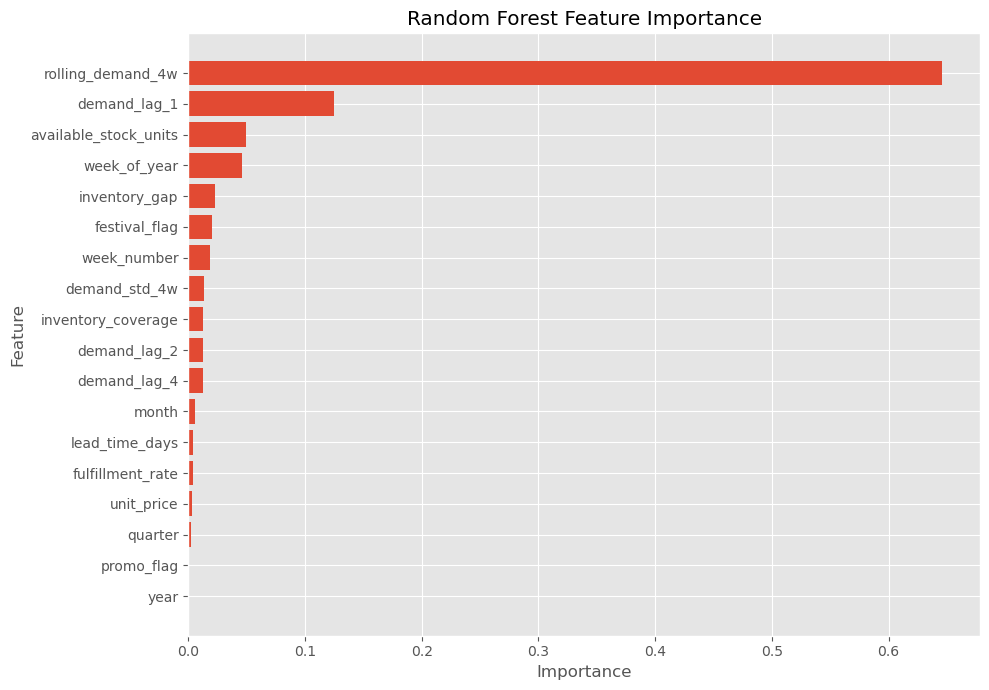

In [292]:
plt.figure(figsize=(10, 7))

plt.barh(
    feature_importance["feature"],
    feature_importance["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

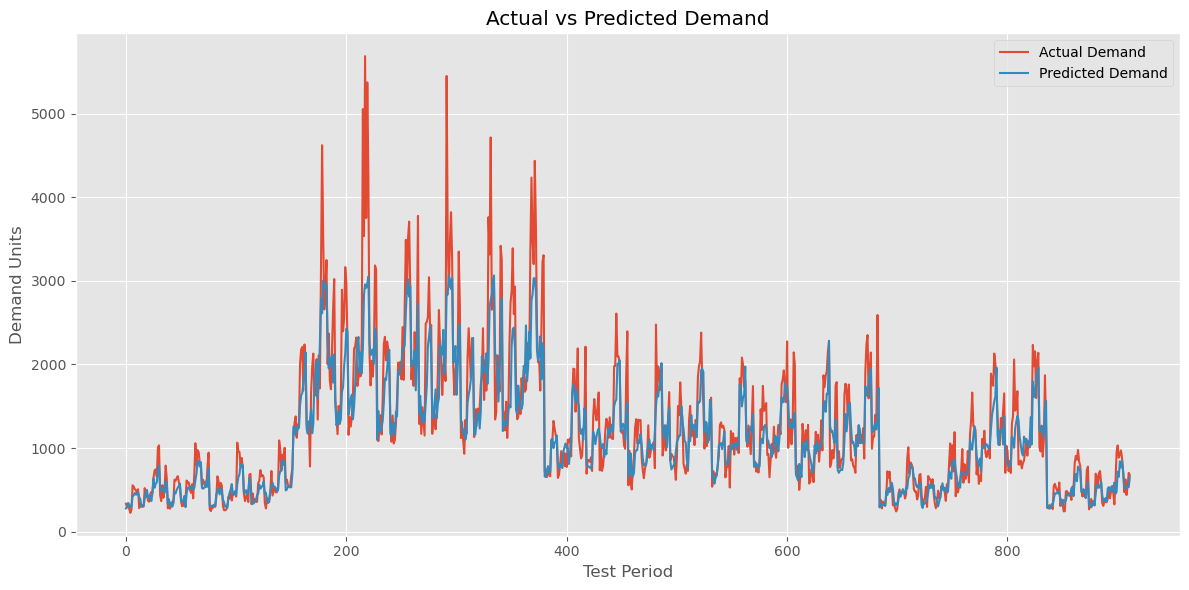

In [293]:
plt.figure(figsize=(12, 6))

plt.plot(
    y_test.values,
    label="Actual Demand"
)

plt.plot(
    rf_pred,
    label="Predicted Demand"
)

plt.title("Actual vs Predicted Demand")
plt.xlabel("Test Period")
plt.ylabel("Demand Units")

plt.legend()
plt.tight_layout()
plt.show()

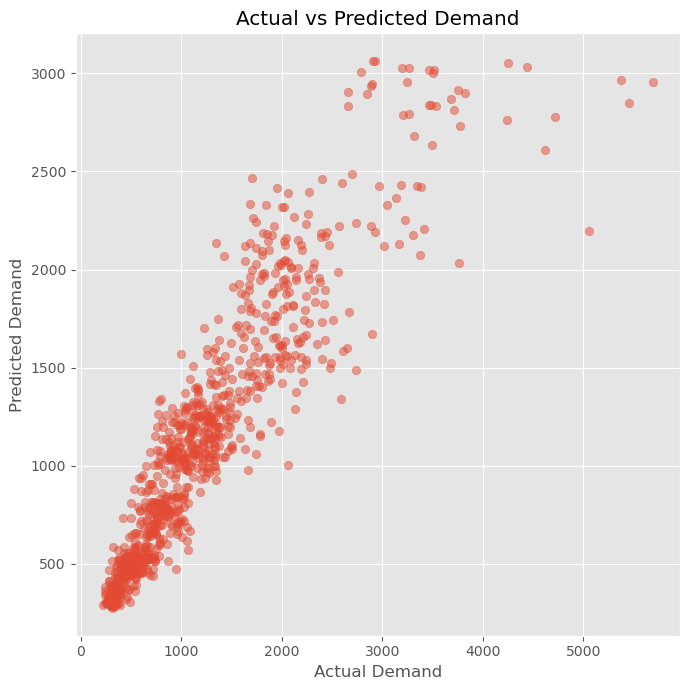

In [294]:
plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    rf_pred,
    alpha=0.5
)

plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title("Actual vs Predicted Demand")

plt.tight_layout()
plt.show()

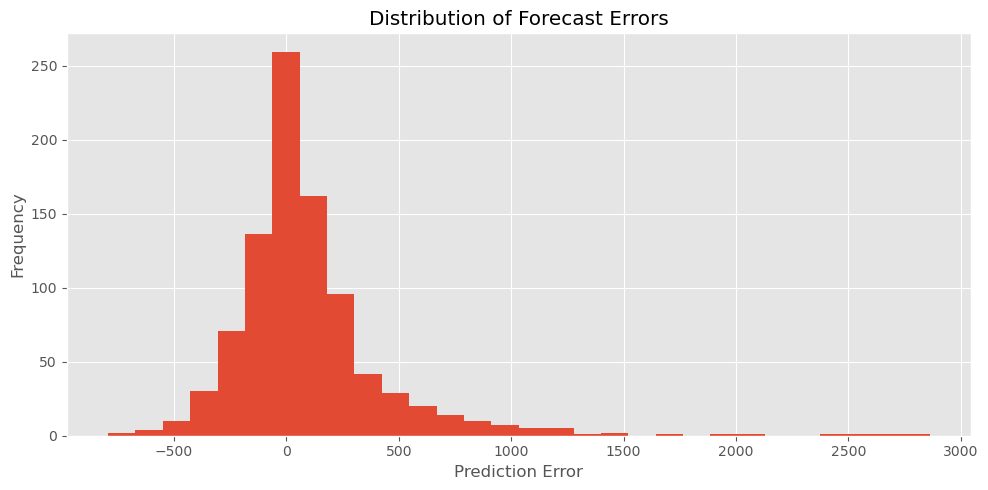

In [295]:
residuals = y_test - rf_pred
plt.figure(figsize=(10, 5))

plt.hist(
    residuals,
    bins=30
)

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Distribution of Forecast Errors")

plt.tight_layout()
plt.show()

In [296]:
results = test[[
    "date",
    "sku_name",
    "warehouse_name",
    "demand_units",
    "target_demand"
]].copy()

results["predicted_demand"] = rf_pred

results["absolute_error"] = (
    abs(results["target_demand"] - results["predicted_demand"])
)

results = results.sort_values(
    "absolute_error",
    ascending=False
)

results.head(20)

,date,sku_name,warehouse_name,demand_units,target_demand,predicted_demand,absolute_error
1234,2025-09-28,Lager 330ml,West DC,2322,5055.0,2194.480021,2860.519979
1236,2025-10-12,Lager 330ml,West DC,3536,5688.0,2958.260423,2729.739577
1650,2025-09-28,Lager 650ml,West DC,1802,5451.0,2849.051485,2601.948515
1238,2025-10-26,Lager 330ml,West DC,3752,5374.0,2968.125041,2405.874959
1027,2025-10-05,Lager 330ml,North DC,3203,4623.0,2611.537887,2011.462113
1860,2025-10-12,Lager Can 500ml,North DC,3316,4716.0,2775.222420,1940.777580
1858,2025-09-28,Lager Can 500ml,North DC,1932,3762.0,2035.286355,1726.713645
2067,2025-10-05,Lager Can 500ml,West DC,3379,4236.0,2763.456583,1472.543417
2070,2025-10-26,Lager Can 500ml,West DC,3201,4436.0,3033.662236,1402.337764
2066,2025-09-28,Lager Can 500ml,West DC,2063,3379.0,2074.095065,1304.904935


In [297]:
accuracy = 100 - (
    np.mean(
        np.abs(
            (y_test - rf_pred) / y_test
        )
    ) * 100
)

print(f"Forecast Accuracy: {accuracy:.2f}%")

Forecast Accuracy: 83.18%


In [298]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [299]:
from xgboost import XGBRegressor

In [300]:
xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)

In [301]:
xgb_model.fit(
    X_train,
    y_train
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [302]:
xgb_pred = xgb_model.predict(X_test)

In [303]:
mae_xgb = mean_absolute_error(
    y_test,
    xgb_pred
)

rmse_xgb = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_pred
    )
)

print("XGBoost MAE:", mae_xgb)
print("XGBoost RMSE:", rmse_xgb)

XGBoost MAE: 230.5441268452427
XGBoost RMSE: 390.050492356693


In [304]:
model_comparison = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        mae_baseline,
        mae_rf,
        mae_xgb
    ],
    "RMSE": [
        rmse_baseline,
        rmse_rf,
        rmse_xgb
    ]
})

model_comparison.sort_values(
    "MAE"
)

,Model,MAE,RMSE
1,Random Forest,219.145074,365.632633
2,XGBoost,230.544127,390.050492
0,Naive Baseline,333.134868,538.047476


In [305]:
best_model_name = model_comparison.loc[
    model_comparison["MAE"].idxmin(),
    "Model"
]

print("Best model based on MAE:", best_model_name)

Best model based on MAE: Random Forest


In [306]:
xgb_importance = pd.DataFrame({
    "feature": features,
    "importance": xgb_model.feature_importances_
})

xgb_importance = (
    xgb_importance
    .sort_values("importance", ascending=False)
)

xgb_importance

,feature,importance
8,rolling_demand_4w,0.415244
12,festival_flag,0.147901
5,demand_lag_1,0.117506
14,available_stock_units,0.069949
4,week_of_year,0.043540
11,lead_time_days,0.036268
2,month,0.029418
17,inventory_gap,0.022141
16,fulfillment_rate,0.019771
0,week_number,0.019011


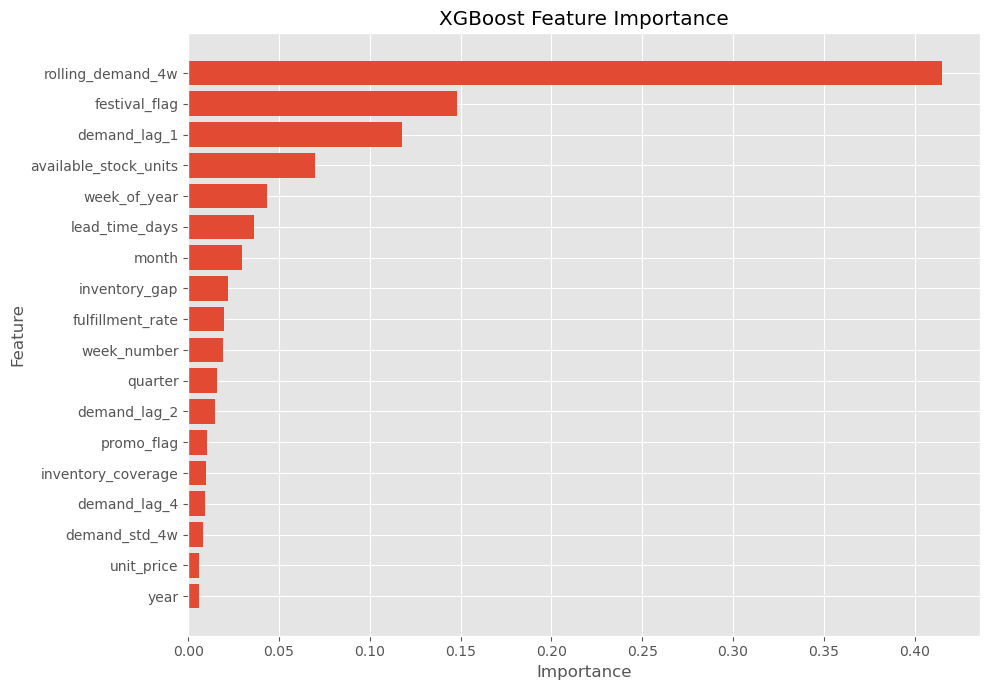

In [307]:
plt.figure(figsize=(10, 7))

plt.barh(
    xgb_importance["feature"],
    xgb_importance["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [308]:
import joblib

joblib.dump(
    xgb_model,
    "demand_forecasting_model.pkl"
)

['demand_forecasting_model.pkl']

In [309]:
joblib.dump(
    rf_model,
    "demand_forecasting_model.pkl"
)

['demand_forecasting_model.pkl']

In [310]:
import joblib

joblib.dump(
    xgb_model,
    "xgboost_demand_model.pkl"
)

print("XGBoost model saved successfully!")

XGBoost model saved successfully!


In [311]:
import joblib

joblib.dump(
    rf_model,
    "random_forest_demand_model.pkl"
)

print("Random Forest model saved successfully!")

Random Forest model saved successfully!


In [312]:
import os

print(os.listdir())

['.ipynb_checkpoints', '01_Data_Understanding.ipynb', '02_Data_Cleaning.ipynb', '02_Load_Data_to_MySQL.ipynb', '03_Business_EDA.ipynb', 'demand_forecasting_model.pkl', 'final_regression_model_comparison.csv', 'linear_regression_demand_model.pkl', 'logistic_stockout_model.pkl', 'model_business_summary.csv', 'random_forest_demand_model.pkl', 'random_forest_stockout_model.pkl', 'stockout_classification_model_comparison.csv', 'stockout_risk_feature_importance.csv', 'xgboost_demand_model.pkl']


In [313]:
import os

print(os.listdir())

['.ipynb_checkpoints', '01_Data_Understanding.ipynb', '02_Data_Cleaning.ipynb', '02_Load_Data_to_MySQL.ipynb', '03_Business_EDA.ipynb', 'demand_forecasting_model.pkl', 'final_regression_model_comparison.csv', 'linear_regression_demand_model.pkl', 'logistic_stockout_model.pkl', 'model_business_summary.csv', 'random_forest_demand_model.pkl', 'random_forest_stockout_model.pkl', 'stockout_classification_model_comparison.csv', 'stockout_risk_feature_importance.csv', 'xgboost_demand_model.pkl']


In [314]:
import joblib

final_model = joblib.load(
    "random_forest_demand_model.pkl"
)

print("Final model loaded successfully!")

Final model loaded successfully!


In [315]:
print(final_model)

RandomForestRegressor(max_depth=12, n_estimators=300, n_jobs=-1,
                      random_state=42)


In [316]:
def predict_demand(input_data):
    prediction = final_model.predict(input_data)
    return prediction

In [317]:
sample_predictions = predict_demand(X_test.head(10))

print(sample_predictions)

[278.63061598 292.72790662 343.9264152  320.64558907 290.15486557
 300.73029724 424.46294995 433.93084807 462.64930478 444.45152943]


In [318]:
prediction_results = pd.DataFrame({
    "Actual_Demand": y_test.values,
    "Predicted_Demand": rf_pred
})

prediction_results.head(10)

,Actual_Demand,Predicted_Demand
0,335.0,278.630616
1,293.0,292.727907
2,309.0,343.926415
3,270.0,320.645589
4,225.0,290.154866
5,264.0,300.730297
6,555.0,424.462950
7,541.0,433.930848
8,508.0,462.649305
9,499.0,444.451529


In [319]:
prediction_results["Absolute_Error"] = (
    abs(
        prediction_results["Actual_Demand"]
        - prediction_results["Predicted_Demand"]
    )
)

prediction_results.head(10)


,Actual_Demand,Predicted_Demand,Absolute_Error
0,335.0,278.630616,56.369384
1,293.0,292.727907,0.272093
2,309.0,343.926415,34.926415
3,270.0,320.645589,50.645589
4,225.0,290.154866,65.154866
5,264.0,300.730297,36.730297
6,555.0,424.462950,130.537050
7,541.0,433.930848,107.069152
8,508.0,462.649305,45.350695
9,499.0,444.451529,54.548471


In [320]:
prediction_results["Percentage_Error"] = (
    prediction_results["Absolute_Error"]
    / prediction_results["Actual_Demand"]
) * 100

prediction_results.head(10)

,Actual_Demand,Predicted_Demand,Absolute_Error,Percentage_Error
0,335.0,278.630616,56.369384,16.826682
1,293.0,292.727907,0.272093,0.092865
2,309.0,343.926415,34.926415,11.303047
3,270.0,320.645589,50.645589,18.757626
4,225.0,290.154866,65.154866,28.957718
5,264.0,300.730297,36.730297,13.912991
6,555.0,424.462950,130.537050,23.520189
7,541.0,433.930848,107.069152,19.790971
8,508.0,462.649305,45.350695,8.927302
9,499.0,444.451529,54.548471,10.931557


In [321]:
worst_predictions = prediction_results.sort_values(
    "Absolute_Error",
    ascending=False
)

worst_predictions.head(10)

,Actual_Demand,Predicted_Demand,Absolute_Error,Percentage_Error
215,5055.0,2194.480021,2860.519979,56.587932
217,5688.0,2958.260423,2729.739577,47.991202
291,5451.0,2849.051485,2601.948515,47.733416
219,5374.0,2968.125041,2405.874959,44.768793
178,4623.0,2611.537887,2011.462113,43.509888
331,4716.0,2775.222420,1940.777580,41.153045
329,3762.0,2035.286355,1726.713645,45.898821
368,4236.0,2763.456583,1472.543417,34.762592
371,4436.0,3033.662236,1402.337764,31.612664
367,3379.0,2074.095065,1304.904935,38.618080


In [322]:
mean_percentage_error = (
    prediction_results["Percentage_Error"].mean()
)

print(
    f"Mean Percentage Error: {mean_percentage_error:.2f}%"
)

Mean Percentage Error: 16.82%


In [323]:
prediction_results["Error"] = (
    prediction_results["Actual_Demand"]
    - prediction_results["Predicted_Demand"]
)
underpredictions = prediction_results[
    prediction_results["Error"] > 0
]

overpredictions = prediction_results[
    prediction_results["Error"] < 0
]

print("Underpredictions:", len(underpredictions))
print("Overpredictions:", len(overpredictions))

Underpredictions: 524
Overpredictions: 388


In [324]:
underprediction_rate = (
    len(underpredictions)
    / len(prediction_results)
) * 100

print(
    f"Underprediction Rate: {underprediction_rate:.2f}%"
)

Underprediction Rate: 57.46%


In [325]:
high_demand_observations = prediction_results[
    prediction_results["Actual_Demand"] > 2000
].copy()

print("High-demand observations:", len(high_demand_observations))

High-demand observations: 141


In [326]:
business_summary = pd.DataFrame({
    "Metric": [
        "Baseline MAE",
        "Random Forest MAE",
        "XGBoost MAE",
        "Baseline RMSE",
        "Random Forest RMSE",
        "XGBoost RMSE",
        "MAE Improvement vs Baseline",
        "RMSE Improvement vs Baseline",
        "Forecast Accuracy",
        "Underprediction Rate",
        "Average Percentage Error",
        "High-Demand Observations",
        "High-Demand MAE"
    ],

    "Value": [
        mae_baseline,
        mae_rf,
        mae_xgb,
        rmse_baseline,
        rmse_rf,
        rmse_xgb,
        mae_improvement,
        rmse_improvement,
        accuracy,
        underprediction_rate,
        mean_percentage_error,
        len(high_demand_observations),
        high_demand_mae
    ]
})

business_summary

,Metric,Value
0,Baseline MAE,333.134868
1,Random Forest MAE,219.145074
2,XGBoost MAE,230.544127
3,Baseline RMSE,538.047476
4,Random Forest RMSE,365.632633
5,XGBoost RMSE,390.050492
6,MAE Improvement vs Baseline,34.217311
7,RMSE Improvement vs Baseline,32.044541
8,Forecast Accuracy,83.179589
9,Underprediction Rate,57.456140


In [327]:
high_demand = prediction_results[
    prediction_results["Actual_Demand"] > 2000
]

print("High-demand observations:", len(high_demand))

high_demand.head(10)

High-demand observations: 141


,Actual_Demand,Predicted_Demand,Absolute_Error,Percentage_Error,Error
158,2014.0,1516.480591,497.519409,24.703049,497.519409
159,2181.0,1632.790899,548.209101,25.135676,548.209101
160,2209.0,1658.468877,550.531123,24.922188,550.531123
162,2239.0,1867.395376,371.604624,16.596901,371.604624
163,2025.0,2144.732366,119.732366,5.912709,-119.732366
170,2130.0,1289.715275,840.284725,39.449987,840.284725
173,2063.0,2038.787909,24.212091,1.173635,24.212091
175,2112.0,1819.507392,292.492608,13.849082,292.492608
177,3203.0,2789.183967,413.816033,12.919639,413.816033
178,4623.0,2611.537887,2011.462113,43.509888,2011.462113


In [328]:
high_demand_mae = (
    high_demand["Absolute_Error"].mean()
)

print(
    f"High-Demand MAE: {high_demand_mae:.2f}"
)

High-Demand MAE: 596.96


In [329]:
high_demand_mae = (
    high_demand["Absolute_Error"].mean()
)

print(
    f"High-Demand MAE: {high_demand_mae:.2f}"
)

High-Demand MAE: 596.96


In [330]:
business_summary.to_csv(
    "model_business_summary.csv",
    index=False
)

print("Business summary saved successfully!")

Business summary saved successfully!


In [331]:
print("========== FINAL MODEL ==========")
print("Model: Random Forest")

print("\n========== PERFORMANCE ==========")
print(f"MAE: {mae_rf:.2f}")
print(f"RMSE: {rmse_rf:.2f}")

print("\n========== BUSINESS ANALYSIS ==========")
print(f"Underprediction Rate: {underprediction_rate:.2f}%")
print(f"Average Percentage Error: {mean_percentage_error:.2f}%")
print(f"High-Demand MAE: {high_demand_mae:.2f}")

print("\n========== FILES ==========")
print("random_forest_demand_model.pkl")
print("xgboost_demand_model.pkl")
print("demand_predictions.csv")
print("model_business_summary.csv")

========== FINAL MODEL ==========
Model: Random Forest

========== PERFORMANCE ==========
MAE: 219.15
RMSE: 365.63

========== BUSINESS ANALYSIS ==========
Underprediction Rate: 57.46%
Average Percentage Error: 16.82%
High-Demand MAE: 596.96

========== FILES ==========
random_forest_demand_model.pkl
xgboost_demand_model.pkl
demand_predictions.csv
model_business_summary.csv


In [332]:
print("Final Model:", type(rf_model).__name__)
print("Test observations:", len(y_test))
print("Predictions:", len(rf_pred))

print("\nMAE:", mae_rf)
print("RMSE:", rmse_rf)

Final Model: RandomForestRegressor
Test observations: 912
Predictions: 912

MAE: 219.14507402983372
RMSE: 365.6326325685676


In [333]:
from sklearn.linear_model import LinearRegression

In [334]:
lr_model = LinearRegression()

lr_model.fit(
    X_train,
    y_train
)

LinearRegression()

In [335]:
lr_pred = lr_model.predict(X_test)

print(lr_pred[:10])

[291.0102827  281.39623627 254.14350267 336.94397041 300.61003781
 252.14111351 245.98550902 405.80671631 409.76633228 401.62605696]


In [336]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_lr = mean_absolute_error(
    y_test,
    lr_pred
)

rmse_lr = np.sqrt(
    mean_squared_error(
        y_test,
        lr_pred
    )
)

print("Linear Regression MAE:", mae_lr)
print("Linear Regression RMSE:", rmse_lr)

Linear Regression MAE: 251.77858920058384
Linear Regression RMSE: 411.13091643655963


In [337]:
regression_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        mae_lr,
        mae_rf
    ],
    "RMSE": [
        rmse_lr,
        rmse_rf
    ]
})

regression_comparison

,Model,MAE,RMSE
0,Linear Regression,251.778589,411.130916
1,Random Forest,219.145074,365.632633


In [338]:
regression_comparison = regression_comparison.sort_values(
    "MAE"
)

regression_comparison

,Model,MAE,RMSE
1,Random Forest,219.145074,365.632633
0,Linear Regression,251.778589,411.130916


In [339]:
mae_rf_vs_lr = (
    (mae_lr - mae_rf)
    / mae_lr
) * 100

rmse_rf_vs_lr = (
    (rmse_lr - rmse_rf)
    / rmse_lr
) * 100

print(
    f"Random Forest MAE improvement vs Linear Regression: "
    f"{mae_rf_vs_lr:.2f}%"
)

print(
    f"Random Forest RMSE improvement vs Linear Regression: "
    f"{rmse_rf_vs_lr:.2f}%"
)

Random Forest MAE improvement vs Linear Regression: 12.96%
Random Forest RMSE improvement vs Linear Regression: 11.07%


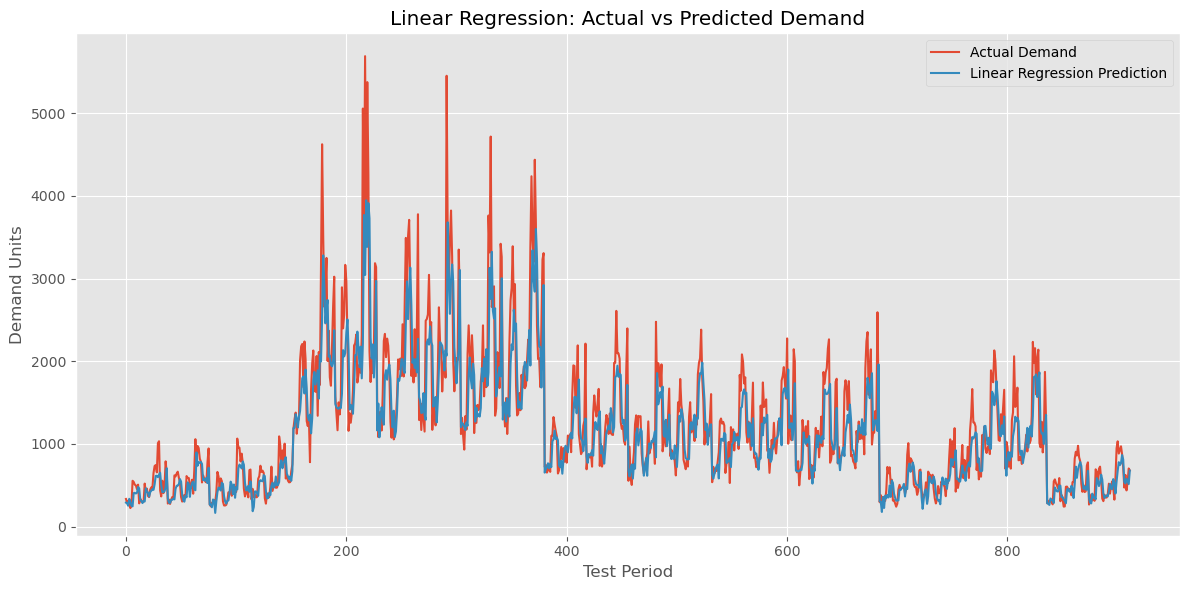

In [340]:
plt.figure(figsize=(12, 6))

plt.plot(
    y_test.values,
    label="Actual Demand"
)

plt.plot(
    lr_pred,
    label="Linear Regression Prediction"
)

plt.xlabel("Test Period")
plt.ylabel("Demand Units")
plt.title("Linear Regression: Actual vs Predicted Demand")

plt.legend()

plt.tight_layout()

plt.show()

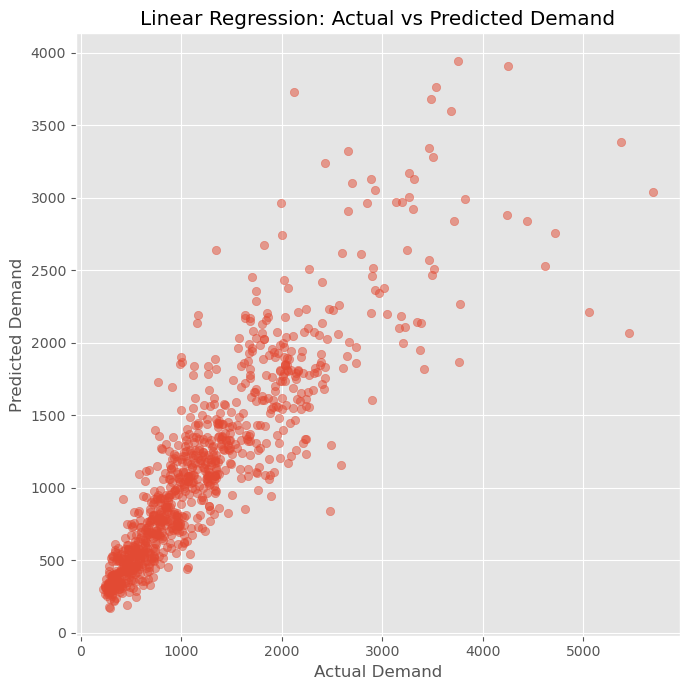

In [341]:
plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    lr_pred,
    alpha=0.5
)

plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title("Linear Regression: Actual vs Predicted Demand")

plt.tight_layout()

plt.show()

In [342]:
lr_coefficients = pd.DataFrame({
    "feature": features,
    "coefficient": lr_model.coef_
})

lr_coefficients

,feature,coefficient
0,week_number,-0.384066
1,year,0.248966
2,month,79.220786
3,quarter,-71.893151
4,week_of_year,-13.330317
5,demand_lag_1,0.044635
6,demand_lag_2,-0.050108
7,demand_lag_4,-0.069893
8,rolling_demand_4w,0.218121
9,demand_std_4w,-0.086139


In [343]:
lr_coefficients = lr_coefficients.sort_values(
    "coefficient",
    ascending=False
)

lr_coefficients

,feature,coefficient
16,fulfillment_rate,258.363289
2,month,79.220786
12,festival_flag,45.273290
14,available_stock_units,0.753795
1,year,0.248966
8,rolling_demand_4w,0.218121
10,unit_price,0.180650
5,demand_lag_1,0.044635
6,demand_lag_2,-0.050108
7,demand_lag_4,-0.069893


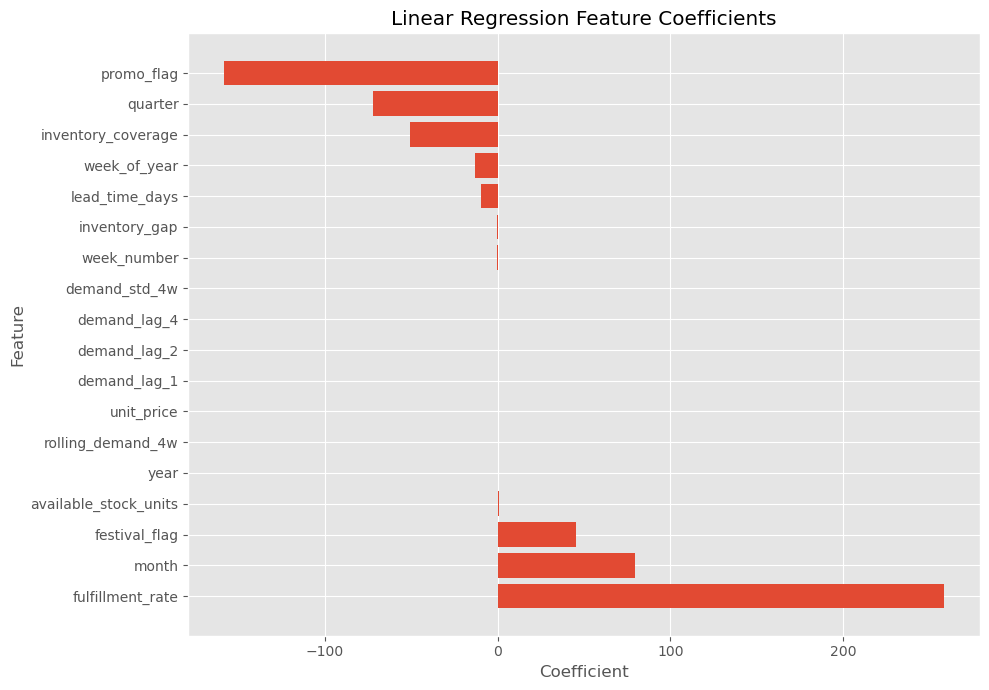

In [344]:
plt.figure(figsize=(10, 7))

plt.barh(
    lr_coefficients["feature"],
    lr_coefficients["coefficient"]
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Linear Regression Feature Coefficients")

plt.tight_layout()

plt.show()

In [345]:
rf_importance = pd.DataFrame({
    "feature": features,
    "rf_importance": rf_model.feature_importances_
})

lr_importance = pd.DataFrame({
    "feature": features,
    "lr_coefficient": lr_model.coef_
})

feature_comparison = rf_importance.merge(
    lr_importance,
    on="feature"
)

feature_comparison

,feature,rf_importance,lr_coefficient
0,week_number,0.018898,-0.384066
1,year,0.000291,0.248966
2,month,0.006163,79.220786
3,quarter,0.002241,-71.893151
4,week_of_year,0.046213,-13.330317
5,demand_lag_1,0.124954,0.044635
6,demand_lag_2,0.012733,-0.050108
7,demand_lag_4,0.012676,-0.069893
8,rolling_demand_4w,0.645935,0.218121
9,demand_std_4w,0.013311,-0.086139


In [346]:
feature_comparison = feature_comparison.sort_values(
    "rf_importance",
    ascending=False
)

feature_comparison

,feature,rf_importance,lr_coefficient
8,rolling_demand_4w,0.645935,0.218121
5,demand_lag_1,0.124954,0.044635
14,available_stock_units,0.049274,0.753795
4,week_of_year,0.046213,-13.330317
17,inventory_gap,0.022586,-0.582150
12,festival_flag,0.020009,45.273290
0,week_number,0.018898,-0.384066
9,demand_std_4w,0.013311,-0.086139
15,inventory_coverage,0.012772,-50.698217
6,demand_lag_2,0.012733,-0.050108


In [347]:
lr_accuracy = 100 - (
    np.mean(
        np.abs(
            (y_test - lr_pred) / y_test
        )
    ) * 100
)

print(
    f"Linear Regression Forecast Accuracy: "
    f"{lr_accuracy:.2f}%"
)

Linear Regression Forecast Accuracy: 80.03%


In [348]:
lr_results = pd.DataFrame({
    "Actual_Demand": y_test.values,
    "Predicted_Demand": lr_pred
})

lr_results["Absolute_Error"] = (
    abs(
        lr_results["Actual_Demand"]
        - lr_results["Predicted_Demand"]
    )
)

lr_results["Percentage_Error"] = (
    lr_results["Absolute_Error"]
    / lr_results["Actual_Demand"]
) * 100

lr_results.head(10)

,Actual_Demand,Predicted_Demand,Absolute_Error,Percentage_Error
0,335.0,291.010283,43.989717,13.131259
1,293.0,281.396236,11.603764,3.960329
2,309.0,254.143503,54.856497,17.752912
3,270.0,336.943970,66.943970,24.794063
4,225.0,300.610038,75.610038,33.604461
5,264.0,252.141114,11.858886,4.492002
6,555.0,245.985509,309.014491,55.678287
7,541.0,405.806716,135.193284,24.989516
8,508.0,409.766332,98.233668,19.337336
9,499.0,401.626057,97.373943,19.513816


In [349]:
lr_worst_predictions = lr_results.sort_values(
    "Absolute_Error",
    ascending=False
)

lr_worst_predictions.head(10)

,Actual_Demand,Predicted_Demand,Absolute_Error,Percentage_Error
291,5451.0,2068.754754,3382.245246,62.048161
215,5055.0,2214.983808,2840.016192,56.182318
217,5688.0,3043.013693,2644.986307,46.501166
178,4623.0,2531.407221,2091.592779,45.243192
219,5374.0,3383.037946,1990.962054,37.048047
331,4716.0,2756.178460,1959.821540,41.556860
329,3762.0,1866.829236,1895.170764,50.376682
481,2477.0,838.754877,1638.245123,66.138277
340,3420.0,1817.225126,1602.774874,46.864762
221,2126.0,3727.809495,1601.809495,75.343814


In [350]:
lr_mean_percentage_error = (
    lr_results["Percentage_Error"].mean()
)

print(
    f"Linear Regression Mean Percentage Error: "
    f"{lr_mean_percentage_error:.2f}%"
)

Linear Regression Mean Percentage Error: 19.97%


In [351]:
final_regression_comparison = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        mae_baseline,
        mae_lr,
        mae_rf,
        mae_xgb
    ],
    "RMSE": [
        rmse_baseline,
        rmse_lr,
        rmse_rf,
        rmse_xgb
    ]
})

final_regression_comparison = (
    final_regression_comparison
    .sort_values("MAE")
    .reset_index(drop=True)
)

final_regression_comparison

,Model,MAE,RMSE
0,Random Forest,219.145074,365.632633
1,XGBoost,230.544127,390.050492
2,Linear Regression,251.778589,411.130916
3,Naive Baseline,333.134868,538.047476


In [352]:
best_regression_model = final_regression_comparison.loc[
    final_regression_comparison["MAE"].idxmin(),
    "Model"
]

print(
    "Best Regression Model based on MAE:",
    best_regression_model
)

Best Regression Model based on MAE: Random Forest


In [353]:
import joblib

joblib.dump(
    lr_model,
    "linear_regression_demand_model.pkl"
)

print(
    "Linear Regression model saved successfully!"
)

Linear Regression model saved successfully!


In [354]:
final_regression_comparison.to_csv(
    "final_regression_model_comparison.csv",
    index=False
)

print(
    "Regression comparison saved successfully!"
)

Regression comparison saved successfully!


In [355]:
print("========== DAY 6 REGRESSION SUMMARY ==========")

print("\nMODEL PERFORMANCE")
print(final_regression_comparison)

print("\nBEST MODEL")
print(best_regression_model)

print("\nRANDOM FOREST VS LINEAR REGRESSION")

print(
    f"MAE improvement: "
    f"{mae_rf_vs_lr:.2f}%"
)

print(
    f"RMSE improvement: "
    f"{rmse_rf_vs_lr:.2f}%"
)

print("\nBUSINESS INTERPRETATION")

print(
    "Linear Regression provides a simple linear benchmark, "
    "while Random Forest captures nonlinear relationships "
    "and interactions between demand history, seasonality "
    "and operational variables."
)

========== DAY 6 REGRESSION SUMMARY ==========

MODEL PERFORMANCE
               Model         MAE        RMSE
0      Random Forest  219.145074  365.632633
1            XGBoost  230.544127  390.050492
2  Linear Regression  251.778589  411.130916
3     Naive Baseline  333.134868  538.047476

BEST MODEL
Random Forest

RANDOM FOREST VS LINEAR REGRESSION
MAE improvement: 12.96%
RMSE improvement: 11.07%

BUSINESS INTERPRETATION
Linear Regression provides a simple linear benchmark, while Random Forest captures nonlinear relationships and interactions between demand history, seasonality and operational variables.


In [356]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [357]:
df_classification = df.copy()

df_classification = df_classification.sort_values(
    ["date", "sku_name", "warehouse_name"]
).reset_index(drop=True)

print(df_classification.shape)

(4992, 29)


In [358]:
print(df_classification["stockout_flag"].value_counts())

stockout_flag
0    4141
1     851
Name: count, dtype: int64


In [359]:
print(
    df_classification["stockout_flag"]
    .value_counts(normalize=True)
    .mul(100)
) #class imbalance 

stockout_flag
0    82.952724
1    17.047276
Name: proportion, dtype: float64


Approximately 83% of observations are non-stockout cases, while around 17% are stockout cases.
This indicates some class imbalance,so I need to evaluate the classifier using precision,
recall and F1-score rather than relying solely on accuracy.

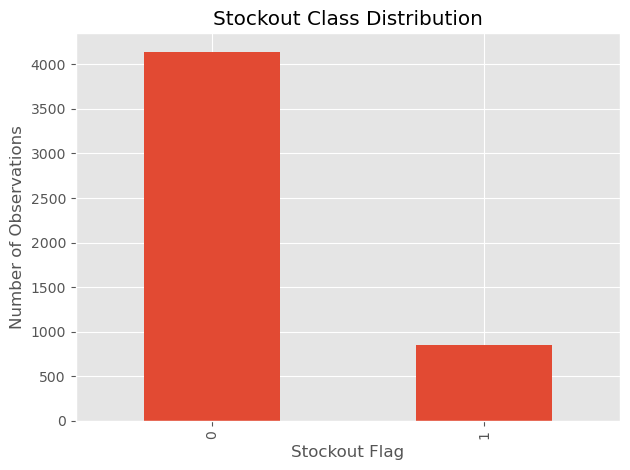

In [360]:
df_classification["stockout_flag"].value_counts().plot(
    kind="bar"
)

plt.xlabel("Stockout Flag")
plt.ylabel("Number of Observations")
plt.title("Stockout Class Distribution")

plt.tight_layout()
plt.show()

In [361]:
classification_features = [
    "week_number",
    "year",
    "month",
    "quarter",
    "week_of_year",
    
    "demand_lag_1",
    "demand_lag_2",
    "demand_lag_4",
    
    "rolling_demand_4w",
    "demand_std_4w",
    
    "unit_price",
    "lead_time_days",
    
    "festival_flag",
    "promo_flag",
    
    "available_stock_units"
]

In [362]:
X_class = df_classification[classification_features]

y_class = df_classification["stockout_flag"]

In [363]:
classification_data = df_classification[
    classification_features + ["stockout_flag"]
].dropna().copy()

print(classification_data.shape)

(4800, 16)


In [364]:
X_class = classification_data[classification_features]

y_class = classification_data["stockout_flag"]

In [365]:
split_index = int(len(X_class) * 0.8)

X_train_class = X_class.iloc[:split_index]
X_test_class = X_class.iloc[split_index:]

y_train_class = y_class.iloc[:split_index]
y_test_class = y_class.iloc[split_index:]

print("Training observations:", len(X_train_class))
print("Testing observations:", len(X_test_class))

Training observations: 3840
Testing observations: 960


In [366]:
print("Training target distribution:")
print(y_train_class.value_counts())

print("\nTesting target distribution:")
print(y_test_class.value_counts())

Training target distribution:
stockout_flag
0    3270
1     570
Name: count, dtype: int64

Testing target distribution:
stockout_flag
0    681
1    279
Name: count, dtype: int64


In [367]:
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        )
    )
])

logistic_model.fit(
    X_train_class,
    y_train_class
)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [368]:
logistic_pred = logistic_model.predict(
    X_test_class
)

print(logistic_pred[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]


In [369]:
logistic_prob = logistic_model.predict_proba(
    X_test_class
)[:, 1]

print(logistic_prob[:20])

[1.12890574e-01 2.73444234e-02 4.12752706e-02 5.24748640e-03
 4.19617589e-02 2.33028849e-02 3.48873070e-02 2.02587912e-01
 1.89534194e-02 1.03713332e-01 4.10635891e-05 2.63772107e-03
 3.77099026e-03 2.44764301e-03 7.94303225e-04 9.87937832e-01
 1.91257994e-02 1.69902337e-04 3.87485596e-02 2.55094957e-01]


In [370]:
precision_lr = precision_score(
    y_test_class,
    logistic_pred,
    zero_division=0
)

recall_lr = recall_score(
    y_test_class,
    logistic_pred,
    zero_division=0
)

f1_lr = f1_score(
    y_test_class,
    logistic_pred,
    zero_division=0
)

print(f"Logistic Regression Precision: {precision_lr:.2f}")
print(f"Logistic Regression Recall: {recall_lr:.2f}")
print(f"Logistic Regression F1 Score: {f1_lr:.2f}")

Logistic Regression Precision: 0.71
Logistic Regression Recall: 0.95
Logistic Regression F1 Score: 0.81


In [371]:
print(
    classification_report(
        y_test_class,
        logistic_pred,
        target_names=[
            "No Stockout",
            "Stockout"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

 No Stockout       0.97      0.84      0.90       681
    Stockout       0.71      0.95      0.81       279

    accuracy                           0.87       960
   macro avg       0.84      0.89      0.86       960
weighted avg       0.90      0.87      0.88       960



In [372]:
cm_lr = confusion_matrix(
    y_test_class,
    logistic_pred
)

print(cm_lr)

[[572 109]
 [ 15 264]]


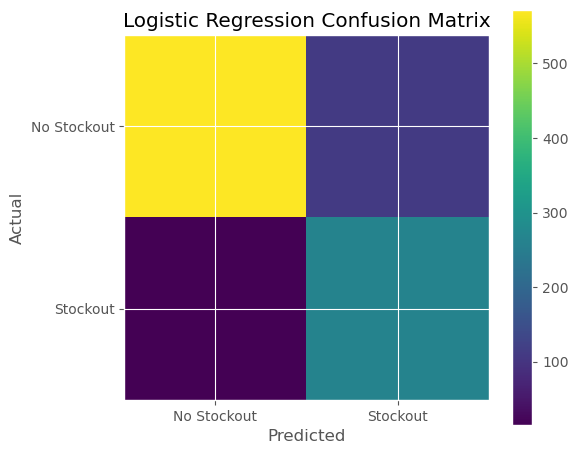

In [373]:
plt.figure(figsize=(6, 5))

plt.imshow(cm_lr)

plt.xticks(
    [0, 1],
    ["No Stockout", "Stockout"]
)

plt.yticks(
    [0, 1],
    ["No Stockout", "Stockout"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Logistic Regression Confusion Matrix")

plt.colorbar()

plt.tight_layout()
plt.show()

In [374]:
rf_classifier = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_classifier.fit(
    X_train_class,
    y_train_class
)

RandomForestClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1,
                       random_state=42)

In [375]:
rf_class_pred = rf_classifier.predict(
    X_test_class
)

print(rf_class_pred[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [376]:
rf_class_prob = rf_classifier.predict_proba(
    X_test_class
)[:, 1]

print(rf_class_prob[:20])

[0.03       0.         0.01       0.00333333 0.00666667 0.00333333
 0.         0.03       0.04666667 0.01666667 0.00666667 0.
 0.         0.00333333 0.02       0.3        0.01333333 0.02333333
 0.01333333 0.03      ]


In [377]:
precision_rf_class = precision_score(
    y_test_class,
    rf_class_pred,
    zero_division=0
)

recall_rf_class = recall_score(
    y_test_class,
    rf_class_pred,
    zero_division=0
)

f1_rf_class = f1_score(
    y_test_class,
    rf_class_pred,
    zero_division=0
)

print(
    f"Random Forest Precision: "
    f"{precision_rf_class:.2f}"
)

print(
    f"Random Forest Recall: "
    f"{recall_rf_class:.2f}"
)

print(
    f"Random Forest F1 Score: "
    f"{f1_rf_class:.2f}"
)

Random Forest Precision: 0.93
Random Forest Recall: 0.62
Random Forest F1 Score: 0.74


In [378]:
print(
    classification_report(
        y_test_class,
        rf_class_pred,
        target_names=[
            "No Stockout",
            "Stockout"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

 No Stockout       0.86      0.98      0.92       681
    Stockout       0.93      0.62      0.74       279

    accuracy                           0.88       960
   macro avg       0.90      0.80      0.83       960
weighted avg       0.88      0.88      0.87       960



In [379]:
cm_rf = confusion_matrix(
    y_test_class,
    rf_class_pred
)

print(cm_rf)

[[669  12]
 [107 172]]


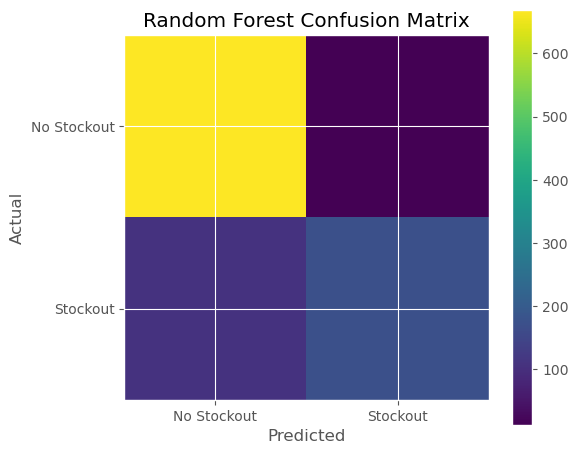

In [380]:
plt.figure(figsize=(6, 5))

plt.imshow(cm_rf)

plt.xticks(
    [0, 1],
    ["No Stockout", "Stockout"]
)

plt.yticks(
    [0, 1],
    ["No Stockout", "Stockout"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Random Forest Confusion Matrix")

plt.colorbar()

plt.tight_layout()
plt.show()

In [381]:
classification_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Precision": [
        precision_lr,
        precision_rf_class
    ],
    "Recall": [
        recall_lr,
        recall_rf_class
    ],
    "F1 Score": [
        f1_lr,
        f1_rf_class
    ]
})

classification_comparison

,Model,Precision,Recall,F1 Score
0,Logistic Regression,0.707775,0.946237,0.809816
1,Random Forest,0.934783,0.616487,0.742981


In [382]:
classification_comparison = (
    classification_comparison
    .sort_values(
        "F1 Score",
        ascending=False
    )
    .reset_index(drop=True)
)

classification_comparison

,Model,Precision,Recall,F1 Score
0,Logistic Regression,0.707775,0.946237,0.809816
1,Random Forest,0.934783,0.616487,0.742981


In [383]:
best_classification_model = (
    classification_comparison
    .loc[
        classification_comparison["F1 Score"].idxmax(),
        "Model"
    ]
)

print(
    "Best Classification Model based on F1 Score:",
    best_classification_model
)

Best Classification Model based on F1 Score: Logistic Regression


In [384]:
rf_class_importance = pd.DataFrame({
    "feature": classification_features,
    "importance": rf_classifier.feature_importances_
})

rf_class_importance = (
    rf_class_importance
    .sort_values(
        "importance",
        ascending=False
    )
)

rf_class_importance

,feature,importance
12,festival_flag,0.202942
14,available_stock_units,0.140727
4,week_of_year,0.111051
0,week_number,0.076235
2,month,0.066709
5,demand_lag_1,0.057774
8,rolling_demand_4w,0.056953
9,demand_std_4w,0.056874
7,demand_lag_4,0.055590
6,demand_lag_2,0.054268


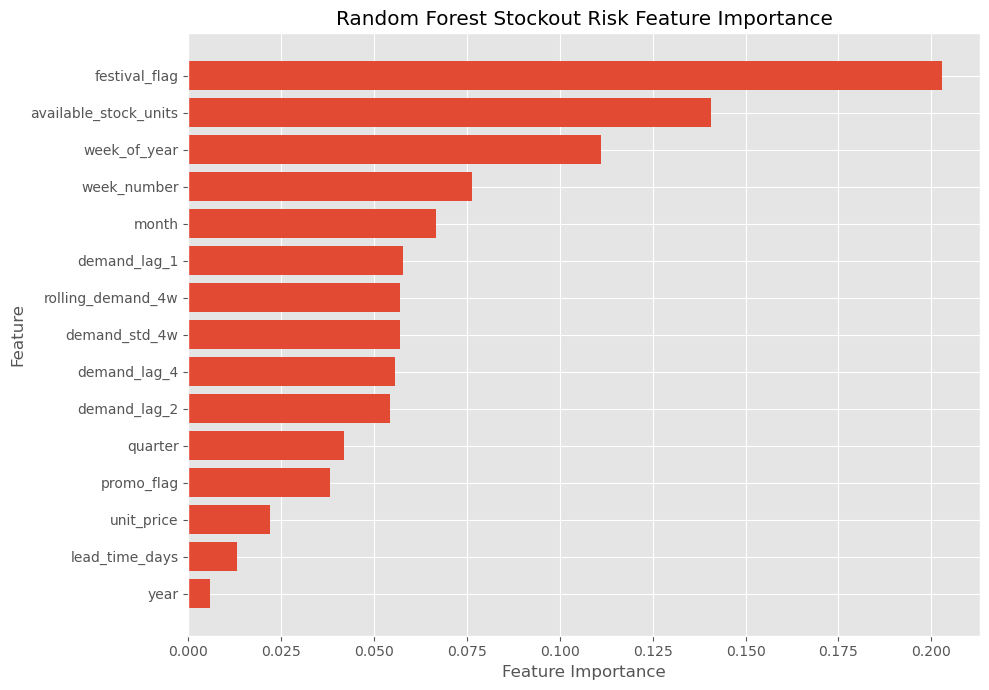

In [385]:
plt.figure(figsize=(10, 7))

plt.barh(
    rf_class_importance["feature"],
    rf_class_importance["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.title(
    "Random Forest Stockout Risk Feature Importance"
)

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [386]:
stockout_results = pd.DataFrame({
    "Actual_Stockout": y_test_class.values,
    "Predicted_Stockout": rf_class_pred,
    "Stockout_Probability": rf_class_prob
})

stockout_results.head(10)

,Actual_Stockout,Predicted_Stockout,Stockout_Probability
0,0,0,0.030000
1,0,0,0.000000
2,0,0,0.010000
3,0,0,0.003333
4,0,0,0.006667
5,0,0,0.003333
6,0,0,0.000000
7,0,0,0.030000
8,0,0,0.046667
9,0,0,0.016667


In [387]:
high_risk = stockout_results[
    stockout_results["Stockout_Probability"] >= 0.70
].copy()

print(
    "High-risk observations:",
    len(high_risk)
)

High-risk observations: 1


In [388]:
high_risk = high_risk.sort_values(
    "Stockout_Probability",
    ascending=False
)

high_risk.head(20)

,Actual_Stockout,Predicted_Stockout,Stockout_Probability
467,1,1,0.716667


In [389]:
classification_comparison.to_csv(
    "stockout_classification_model_comparison.csv",
    index=False
)

print(
    "Classification model comparison saved!"
)

Classification model comparison saved!


In [390]:
rf_class_importance.to_csv(
    "stockout_risk_feature_importance.csv",
    index=False
)

print(
    "Stockout risk feature importance saved!"
)

Stockout risk feature importance saved!


In [391]:
import joblib

joblib.dump(
    logistic_model,
    "logistic_stockout_model.pkl"
)

joblib.dump(
    rf_classifier,
    "random_forest_stockout_model.pkl"
)

print("Stockout classification models saved successfully!")

Stockout classification models saved successfully!


In [392]:
print("========== DAY 7 STOCKOUT CLASSIFICATION SUMMARY ==========")

print("\nMODEL PERFORMANCE")
print(classification_comparison)

print("\nBEST MODEL")
print(best_classification_model)

print("\nKEY BUSINESS METRIC")
print(
    f"Random Forest Recall: "
    f"{recall_rf_class:.2f}"
)

print(
    "\nBUSINESS INTERPRETATION"
)

print(
    "The classification models estimate the probability "
    "of stockout risk for SKU-warehouse observations. "
    "Recall is particularly important because missing an "
    "actual stockout can lead to lost sales and poor service levels."
)

========== DAY 7 STOCKOUT CLASSIFICATION SUMMARY ==========

MODEL PERFORMANCE
                 Model  Precision    Recall  F1 Score
0  Logistic Regression   0.707775  0.946237  0.809816
1        Random Forest   0.934783  0.616487  0.742981

BEST MODEL
Logistic Regression

KEY BUSINESS METRIC
Random Forest Recall: 0.62

BUSINESS INTERPRETATION
The classification models estimate the probability of stockout risk for SKU-warehouse observations. Recall is particularly important because missing an actual stockout can lead to lost sales and poor service levels.


In [393]:
thresholds = [
    0.20,
    0.30,
    0.40,
    0.50,
    0.60,
    0.70,
    0.80
]

threshold_results = []

for threshold in thresholds:

    threshold_pred = (
        logistic_prob >= threshold
    ).astype(int)

    precision = precision_score(
        y_test_class,
        threshold_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test_class,
        threshold_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test_class,
        threshold_pred,
        zero_division=0
    )

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

threshold_results = pd.DataFrame(
    threshold_results
)

threshold_results

,Threshold,Precision,Recall,F1 Score
0,0.2,0.602198,0.982079,0.746594
1,0.3,0.649038,0.967742,0.776978
2,0.4,0.681122,0.956989,0.795827
3,0.5,0.707775,0.946237,0.809816
4,0.6,0.725275,0.946237,0.821151
5,0.7,0.755882,0.921147,0.830372
6,0.8,0.797428,0.888889,0.840678


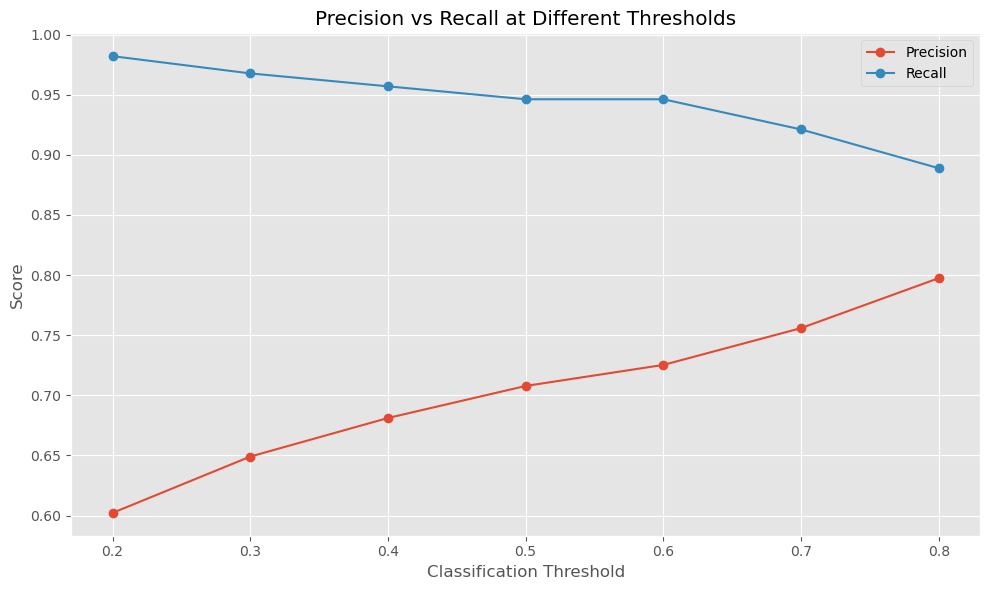

In [394]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    marker="o",
    label="Recall"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision vs Recall at Different Thresholds")

plt.legend()

plt.tight_layout()

plt.show()

In [395]:
best_threshold = threshold_results.loc[
    threshold_results["F1 Score"].idxmax(),
    "Threshold"
]

print(
    "Best Threshold based on F1 Score:",
    best_threshold
)

Best Threshold based on F1 Score: 0.8


In [396]:
logistic_tuned_pred = (
    logistic_prob >= best_threshold
).astype(int)

In [397]:
default_precision = precision_score(
    y_test_class,
    logistic_pred,
    zero_division=0
)

default_recall = recall_score(
    y_test_class,
    logistic_pred,
    zero_division=0
)

default_f1 = f1_score(
    y_test_class,
    logistic_pred,
    zero_division=0
)

tuned_precision = precision_score(
    y_test_class,
    logistic_tuned_pred,
    zero_division=0
)

tuned_recall = recall_score(
    y_test_class,
    logistic_tuned_pred,
    zero_division=0
)

tuned_f1 = f1_score(
    y_test_class,
    logistic_tuned_pred,
    zero_division=0
)

threshold_comparison = pd.DataFrame({
    "Version": [
        "Default Threshold",
        "Optimized Threshold"
    ],
    "Threshold": [
        0.50,
        best_threshold
    ],
    "Precision": [
        default_precision,
        tuned_precision
    ],
    "Recall": [
        default_recall,
        tuned_recall
    ],
    "F1 Score": [
        default_f1,
        tuned_f1
    ]
})

threshold_comparison

,Version,Threshold,Precision,Recall,F1 Score
0,Default Threshold,0.5,0.707775,0.946237,0.809816
1,Optimized Threshold,0.8,0.797428,0.888889,0.840678


In [398]:
cm_tuned = confusion_matrix(
    y_test_class,
    logistic_tuned_pred
)

print(cm_tuned)

[[618  63]
 [ 31 248]]


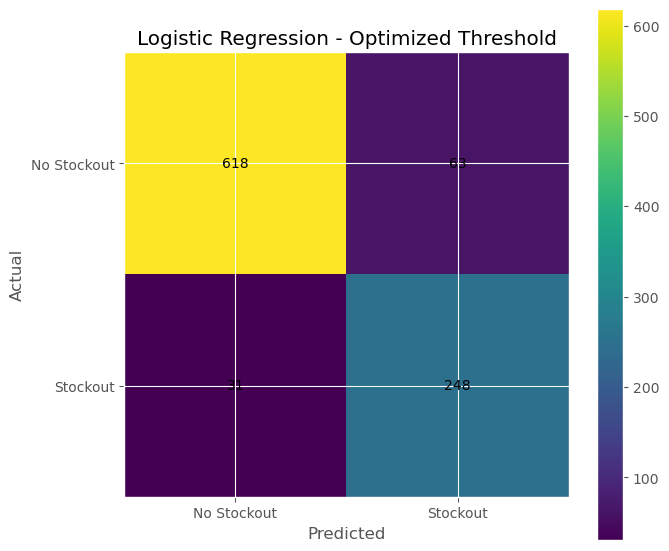

In [399]:
plt.figure(figsize=(7, 6))

plt.imshow(cm_tuned)

plt.xticks(
    [0, 1],
    ["No Stockout", "Stockout"]
)

plt.yticks(
    [0, 1],
    ["No Stockout", "Stockout"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "Logistic Regression - Optimized Threshold"
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm_tuned[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.tight_layout()

plt.show()

In [400]:
print(
    classification_report(
        y_test_class,
        logistic_tuned_pred,
        target_names=[
            "No Stockout",
            "Stockout"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

 No Stockout       0.95      0.91      0.93       681
    Stockout       0.80      0.89      0.84       279

    accuracy                           0.90       960
   macro avg       0.87      0.90      0.89       960
weighted avg       0.91      0.90      0.90       960



In [401]:
classification_results = pd.DataFrame({
    "Actual_Stockout": y_test_class.values,
    "Predicted_Stockout": logistic_tuned_pred,
    "Stockout_Probability": logistic_prob
})

classification_results.head(10)


,Actual_Stockout,Predicted_Stockout,Stockout_Probability
0,0,0,0.112891
1,0,0,0.027344
2,0,0,0.041275
3,0,0,0.005247
4,0,0,0.041962
5,0,0,0.023303
6,0,0,0.034887
7,0,0,0.202588
8,0,0,0.018953
9,0,0,0.103713


In [402]:
high_risk_cases = classification_results[
    classification_results["Stockout_Probability"] >= 0.70
].copy()

high_risk_cases.head(20)

,Actual_Stockout,Predicted_Stockout,Stockout_Probability
15,1,1,0.987938
54,0,1,0.802975
86,1,0,0.703938
253,1,1,0.962587
278,1,0,0.772842
336,1,1,0.895501
337,1,1,0.946108
338,1,1,0.916807
340,0,1,0.958252
341,1,1,0.968944


# DAY 9 — INVENTORY OPTIMIZATION

In [403]:
import numpy as np
import pandas as pd 


In [404]:
inventory_base = (
    df_model
    .groupby(
        ["sku_name", "warehouse_name"]
    )
    .agg(
        average_weekly_demand=("demand_units", "mean"),
        weekly_demand_std=("demand_units", "std"),
        average_lead_time_days=("lead_time_days", "mean"),
        unit_price=("unit_price", "mean")
    )
    .reset_index()
)

inventory_base.head()

,sku_name,warehouse_name,average_weekly_demand,weekly_demand_std,average_lead_time_days,unit_price
0,Cider 500ml,East DC,356.484848,89.046578,10.0,130.0
1,Cider 500ml,North DC,561.101010,166.185076,10.0,130.0
2,Cider 500ml,South DC,422.919192,112.334202,10.0,130.0
3,Cider 500ml,West DC,629.929293,167.349887,10.0,130.0
4,Craft IPA 330ml,East DC,360.202020,98.098865,8.0,180.0


In [405]:
inventory_base['average_daily_demand'] = (inventory_base['average_weekly_demand']/7)
inventory_base.head()

,sku_name,warehouse_name,average_weekly_demand,weekly_demand_std,average_lead_time_days,unit_price,average_daily_demand
0,Cider 500ml,East DC,356.484848,89.046578,10.0,130.0,50.926407
1,Cider 500ml,North DC,561.101010,166.185076,10.0,130.0,80.157287
2,Cider 500ml,South DC,422.919192,112.334202,10.0,130.0,60.417027
3,Cider 500ml,West DC,629.929293,167.349887,10.0,130.0,89.989899
4,Craft IPA 330ml,East DC,360.202020,98.098865,8.0,180.0,51.457431


In [406]:
inventory_base["lead_time_weeks"] = (
    inventory_base["average_lead_time_days"] / 7
)

inventory_base["lead_time_demand_std"] = (
    inventory_base["weekly_demand_std"]
    * np.sqrt(inventory_base["lead_time_weeks"])
)

inventory_base.head()

,sku_name,warehouse_name,average_weekly_demand,weekly_demand_std,average_lead_time_days,unit_price,average_daily_demand,lead_time_weeks,lead_time_demand_std
0,Cider 500ml,East DC,356.484848,89.046578,10.0,130.0,50.926407,1.428571,106.431018
1,Cider 500ml,North DC,561.101010,166.185076,10.0,130.0,80.157287,1.428571,198.629157
2,Cider 500ml,South DC,422.919192,112.334202,10.0,130.0,60.417027,1.428571,134.265052
3,Cider 500ml,West DC,629.929293,167.349887,10.0,130.0,89.989899,1.428571,200.021373
4,Craft IPA 330ml,East DC,360.202020,98.098865,8.0,180.0,51.457431,1.142857,104.872098


In [407]:
z_score = 1.65

print("Z-score:", z_score)

Z-score: 1.65


In [408]:
inventory_base["safety_stock"] = (
    z_score
    * inventory_base["lead_time_demand_std"]
)

inventory_base.head()

,sku_name,warehouse_name,average_weekly_demand,weekly_demand_std,average_lead_time_days,unit_price,average_daily_demand,lead_time_weeks,lead_time_demand_std,safety_stock
0,Cider 500ml,East DC,356.484848,89.046578,10.0,130.0,50.926407,1.428571,106.431018,175.611180
1,Cider 500ml,North DC,561.101010,166.185076,10.0,130.0,80.157287,1.428571,198.629157,327.738110
2,Cider 500ml,South DC,422.919192,112.334202,10.0,130.0,60.417027,1.428571,134.265052,221.537336
3,Cider 500ml,West DC,629.929293,167.349887,10.0,130.0,89.989899,1.428571,200.021373,330.035265
4,Craft IPA 330ml,East DC,360.202020,98.098865,8.0,180.0,51.457431,1.142857,104.872098,173.038962


In [409]:
inventory_base["lead_time_demand"] = (
    inventory_base["average_daily_demand"]
    * inventory_base["average_lead_time_days"]
)

inventory_base.head()

,sku_name,warehouse_name,average_weekly_demand,weekly_demand_std,average_lead_time_days,unit_price,average_daily_demand,lead_time_weeks,lead_time_demand_std,safety_stock,lead_time_demand
0,Cider 500ml,East DC,356.484848,89.046578,10.0,130.0,50.926407,1.428571,106.431018,175.611180,509.264069
1,Cider 500ml,North DC,561.101010,166.185076,10.0,130.0,80.157287,1.428571,198.629157,327.738110,801.572872
2,Cider 500ml,South DC,422.919192,112.334202,10.0,130.0,60.417027,1.428571,134.265052,221.537336,604.170274
3,Cider 500ml,West DC,629.929293,167.349887,10.0,130.0,89.989899,1.428571,200.021373,330.035265,899.898990
4,Craft IPA 330ml,East DC,360.202020,98.098865,8.0,180.0,51.457431,1.142857,104.872098,173.038962,411.659452


In [410]:
inventory_base["reorder_point"] = (
    inventory_base["lead_time_demand"]
    + inventory_base["safety_stock"]
)

inventory_base.head()

,sku_name,warehouse_name,average_weekly_demand,weekly_demand_std,average_lead_time_days,unit_price,average_daily_demand,lead_time_weeks,lead_time_demand_std,safety_stock,lead_time_demand,reorder_point
0,Cider 500ml,East DC,356.484848,89.046578,10.0,130.0,50.926407,1.428571,106.431018,175.611180,509.264069,684.875249
1,Cider 500ml,North DC,561.101010,166.185076,10.0,130.0,80.157287,1.428571,198.629157,327.738110,801.572872,1129.310981
2,Cider 500ml,South DC,422.919192,112.334202,10.0,130.0,60.417027,1.428571,134.265052,221.537336,604.170274,825.707611
3,Cider 500ml,West DC,629.929293,167.349887,10.0,130.0,89.989899,1.428571,200.021373,330.035265,899.898990,1229.934255
4,Craft IPA 330ml,East DC,360.202020,98.098865,8.0,180.0,51.457431,1.142857,104.872098,173.038962,411.659452,584.698414


In [411]:
inventory_base["annual_demand"] = (
    inventory_base["average_weekly_demand"]
    * 52
)

inventory_base.head()

,sku_name,warehouse_name,average_weekly_demand,weekly_demand_std,average_lead_time_days,unit_price,average_daily_demand,lead_time_weeks,lead_time_demand_std,safety_stock,lead_time_demand,reorder_point,annual_demand
0,Cider 500ml,East DC,356.484848,89.046578,10.0,130.0,50.926407,1.428571,106.431018,175.611180,509.264069,684.875249,18537.212121
1,Cider 500ml,North DC,561.101010,166.185076,10.0,130.0,80.157287,1.428571,198.629157,327.738110,801.572872,1129.310981,29177.252525
2,Cider 500ml,South DC,422.919192,112.334202,10.0,130.0,60.417027,1.428571,134.265052,221.537336,604.170274,825.707611,21991.797980
3,Cider 500ml,West DC,629.929293,167.349887,10.0,130.0,89.989899,1.428571,200.021373,330.035265,899.898990,1229.934255,32756.323232
4,Craft IPA 330ml,East DC,360.202020,98.098865,8.0,180.0,51.457431,1.142857,104.872098,173.038962,411.659452,584.698414,18730.505051


In [412]:
ordering_cost = 100

holding_rate = 0.20

print("Assumed ordering cost:", ordering_cost)
print("Assumed annual holding cost rate:", holding_rate)

Assumed ordering cost: 100
Assumed annual holding cost rate: 0.2


In [413]:
inventory_base["annual_holding_cost_per_unit"] = (
    inventory_base["unit_price"]
    * holding_rate
)

inventory_base.head()

,sku_name,warehouse_name,average_weekly_demand,weekly_demand_std,average_lead_time_days,unit_price,average_daily_demand,lead_time_weeks,lead_time_demand_std,safety_stock,lead_time_demand,reorder_point,annual_demand,annual_holding_cost_per_unit
0,Cider 500ml,East DC,356.484848,89.046578,10.0,130.0,50.926407,1.428571,106.431018,175.611180,509.264069,684.875249,18537.212121,26.0
1,Cider 500ml,North DC,561.101010,166.185076,10.0,130.0,80.157287,1.428571,198.629157,327.738110,801.572872,1129.310981,29177.252525,26.0
2,Cider 500ml,South DC,422.919192,112.334202,10.0,130.0,60.417027,1.428571,134.265052,221.537336,604.170274,825.707611,21991.797980,26.0
3,Cider 500ml,West DC,629.929293,167.349887,10.0,130.0,89.989899,1.428571,200.021373,330.035265,899.898990,1229.934255,32756.323232,26.0
4,Craft IPA 330ml,East DC,360.202020,98.098865,8.0,180.0,51.457431,1.142857,104.872098,173.038962,411.659452,584.698414,18730.505051,36.0


In [414]:
inventory_base["eoq"] = np.sqrt(
    (
        2
        * inventory_base["annual_demand"]
        * ordering_cost
    )
    / inventory_base["annual_holding_cost_per_unit"]
)

inventory_base.head()

,sku_name,warehouse_name,average_weekly_demand,weekly_demand_std,average_lead_time_days,unit_price,average_daily_demand,lead_time_weeks,lead_time_demand_std,safety_stock,lead_time_demand,reorder_point,annual_demand,annual_holding_cost_per_unit,eoq
0,Cider 500ml,East DC,356.484848,89.046578,10.0,130.0,50.926407,1.428571,106.431018,175.611180,509.264069,684.875249,18537.212121,26.0,377.616127
1,Cider 500ml,North DC,561.101010,166.185076,10.0,130.0,80.157287,1.428571,198.629157,327.738110,801.572872,1129.310981,29177.252525,26.0,473.751416
2,Cider 500ml,South DC,422.919192,112.334202,10.0,130.0,60.417027,1.428571,134.265052,221.537336,604.170274,825.707611,21991.797980,26.0,411.299984
3,Cider 500ml,West DC,629.929293,167.349887,10.0,130.0,89.989899,1.428571,200.021373,330.035265,899.898990,1229.934255,32756.323232,26.0,501.967845
4,Craft IPA 330ml,East DC,360.202020,98.098865,8.0,180.0,51.457431,1.142857,104.872098,173.038962,411.659452,584.698414,18730.505051,36.0,322.580783


In [415]:
inventory_base["safety_stock"] = (
    inventory_base["safety_stock"].round(0)
)

inventory_base["lead_time_demand"] = (
    inventory_base["lead_time_demand"].round(0)
)

inventory_base["reorder_point"] = (
    inventory_base["reorder_point"].round(0)
)

inventory_base["eoq"] = (
    inventory_base["eoq"].round(0)
)

inventory_base.head()

,sku_name,warehouse_name,average_weekly_demand,weekly_demand_std,average_lead_time_days,unit_price,average_daily_demand,lead_time_weeks,lead_time_demand_std,safety_stock,lead_time_demand,reorder_point,annual_demand,annual_holding_cost_per_unit,eoq
0,Cider 500ml,East DC,356.484848,89.046578,10.0,130.0,50.926407,1.428571,106.431018,176.0,509.0,685.0,18537.212121,26.0,378.0
1,Cider 500ml,North DC,561.101010,166.185076,10.0,130.0,80.157287,1.428571,198.629157,328.0,802.0,1129.0,29177.252525,26.0,474.0
2,Cider 500ml,South DC,422.919192,112.334202,10.0,130.0,60.417027,1.428571,134.265052,222.0,604.0,826.0,21991.797980,26.0,411.0
3,Cider 500ml,West DC,629.929293,167.349887,10.0,130.0,89.989899,1.428571,200.021373,330.0,900.0,1230.0,32756.323232,26.0,502.0
4,Craft IPA 330ml,East DC,360.202020,98.098865,8.0,180.0,51.457431,1.142857,104.872098,173.0,412.0,585.0,18730.505051,36.0,323.0


In [416]:
latest_inventory = (
    df
    .sort_values("date")
    .groupby(
        ["sku_name", "warehouse_name"]
    )
    .tail(1)
    [
        [
            "sku_name",
            "warehouse_name",
            "date",
            "available_stock_units"
        ]
    ]
)

latest_inventory.head()

,sku_name,warehouse_name,date,available_stock_units
2495,Light Beer 330ml,West DC,2025-12-28,2414
4783,Wheat Beer 650ml,North DC,2025-12-28,838
2079,Lager Can 500ml,West DC,2025-12-28,3647
1975,Lager Can 500ml,South DC,2025-12-28,2816
1871,Lager Can 500ml,North DC,2025-12-28,3431


In [417]:
inventory_base = inventory_base.merge(
    latest_inventory,
    on=["sku_name", "warehouse_name"],
    how="left"
)

inventory_base.head()

,sku_name,warehouse_name,average_weekly_demand,weekly_demand_std,average_lead_time_days,unit_price,average_daily_demand,lead_time_weeks,lead_time_demand_std,safety_stock,lead_time_demand,reorder_point,annual_demand,annual_holding_cost_per_unit,eoq,date,available_stock_units
0,Cider 500ml,East DC,356.484848,89.046578,10.0,130.0,50.926407,1.428571,106.431018,176.0,509.0,685.0,18537.212121,26.0,378.0,2025-12-28,472
1,Cider 500ml,North DC,561.101010,166.185076,10.0,130.0,80.157287,1.428571,198.629157,328.0,802.0,1129.0,29177.252525,26.0,474.0,2025-12-28,878
2,Cider 500ml,South DC,422.919192,112.334202,10.0,130.0,60.417027,1.428571,134.265052,222.0,604.0,826.0,21991.797980,26.0,411.0,2025-12-28,694
3,Cider 500ml,West DC,629.929293,167.349887,10.0,130.0,89.989899,1.428571,200.021373,330.0,900.0,1230.0,32756.323232,26.0,502.0,2025-12-28,764
4,Craft IPA 330ml,East DC,360.202020,98.098865,8.0,180.0,51.457431,1.142857,104.872098,173.0,412.0,585.0,18730.505051,36.0,323.0,2025-12-28,709


In [418]:
inventory_base["inventory_gap"] = (
    inventory_base["available_stock_units"]
    - inventory_base["reorder_point"]
)

inventory_base.head()

,sku_name,warehouse_name,average_weekly_demand,weekly_demand_std,average_lead_time_days,unit_price,average_daily_demand,lead_time_weeks,lead_time_demand_std,safety_stock,lead_time_demand,reorder_point,annual_demand,annual_holding_cost_per_unit,eoq,date,available_stock_units,inventory_gap
0,Cider 500ml,East DC,356.484848,89.046578,10.0,130.0,50.926407,1.428571,106.431018,176.0,509.0,685.0,18537.212121,26.0,378.0,2025-12-28,472,-213.0
1,Cider 500ml,North DC,561.101010,166.185076,10.0,130.0,80.157287,1.428571,198.629157,328.0,802.0,1129.0,29177.252525,26.0,474.0,2025-12-28,878,-251.0
2,Cider 500ml,South DC,422.919192,112.334202,10.0,130.0,60.417027,1.428571,134.265052,222.0,604.0,826.0,21991.797980,26.0,411.0,2025-12-28,694,-132.0
3,Cider 500ml,West DC,629.929293,167.349887,10.0,130.0,89.989899,1.428571,200.021373,330.0,900.0,1230.0,32756.323232,26.0,502.0,2025-12-28,764,-466.0
4,Craft IPA 330ml,East DC,360.202020,98.098865,8.0,180.0,51.457431,1.142857,104.872098,173.0,412.0,585.0,18730.505051,36.0,323.0,2025-12-28,709,124.0


In [419]:
inventory_base["inventory_action"] = np.where(
    inventory_base["available_stock_units"]
    <= inventory_base["reorder_point"],
    "Reorder",
    "No Immediate Reorder"
)

inventory_base.head()

,sku_name,warehouse_name,average_weekly_demand,weekly_demand_std,average_lead_time_days,unit_price,average_daily_demand,lead_time_weeks,lead_time_demand_std,safety_stock,lead_time_demand,reorder_point,annual_demand,annual_holding_cost_per_unit,eoq,date,available_stock_units,inventory_gap,inventory_action
0,Cider 500ml,East DC,356.484848,89.046578,10.0,130.0,50.926407,1.428571,106.431018,176.0,509.0,685.0,18537.212121,26.0,378.0,2025-12-28,472,-213.0,Reorder
1,Cider 500ml,North DC,561.101010,166.185076,10.0,130.0,80.157287,1.428571,198.629157,328.0,802.0,1129.0,29177.252525,26.0,474.0,2025-12-28,878,-251.0,Reorder
2,Cider 500ml,South DC,422.919192,112.334202,10.0,130.0,60.417027,1.428571,134.265052,222.0,604.0,826.0,21991.797980,26.0,411.0,2025-12-28,694,-132.0,Reorder
3,Cider 500ml,West DC,629.929293,167.349887,10.0,130.0,89.989899,1.428571,200.021373,330.0,900.0,1230.0,32756.323232,26.0,502.0,2025-12-28,764,-466.0,Reorder
4,Craft IPA 330ml,East DC,360.202020,98.098865,8.0,180.0,51.457431,1.142857,104.872098,173.0,412.0,585.0,18730.505051,36.0,323.0,2025-12-28,709,124.0,No Immediate Reorder


In [420]:
inventory_base["recommended_order_quantity"] = np.where(
    inventory_base["inventory_action"] == "Reorder",
    inventory_base["eoq"],
    0
)

inventory_base.head()

,sku_name,warehouse_name,average_weekly_demand,weekly_demand_std,average_lead_time_days,unit_price,average_daily_demand,lead_time_weeks,lead_time_demand_std,safety_stock,lead_time_demand,reorder_point,annual_demand,annual_holding_cost_per_unit,eoq,date,available_stock_units,inventory_gap,inventory_action,recommended_order_quantity
0,Cider 500ml,East DC,356.484848,89.046578,10.0,130.0,50.926407,1.428571,106.431018,176.0,509.0,685.0,18537.212121,26.0,378.0,2025-12-28,472,-213.0,Reorder,378.0
1,Cider 500ml,North DC,561.101010,166.185076,10.0,130.0,80.157287,1.428571,198.629157,328.0,802.0,1129.0,29177.252525,26.0,474.0,2025-12-28,878,-251.0,Reorder,474.0
2,Cider 500ml,South DC,422.919192,112.334202,10.0,130.0,60.417027,1.428571,134.265052,222.0,604.0,826.0,21991.797980,26.0,411.0,2025-12-28,694,-132.0,Reorder,411.0
3,Cider 500ml,West DC,629.929293,167.349887,10.0,130.0,89.989899,1.428571,200.021373,330.0,900.0,1230.0,32756.323232,26.0,502.0,2025-12-28,764,-466.0,Reorder,502.0
4,Craft IPA 330ml,East DC,360.202020,98.098865,8.0,180.0,51.457431,1.142857,104.872098,173.0,412.0,585.0,18730.505051,36.0,323.0,2025-12-28,709,124.0,No Immediate Reorder,0.0


In [421]:
inventory_base["excess_inventory"] = np.where(
    inventory_base["available_stock_units"]
    > (
        inventory_base["reorder_point"]
        + inventory_base["eoq"]
    ),
    inventory_base["available_stock_units"]
    - inventory_base["reorder_point"],
    0
)

inventory_base.head()

,sku_name,warehouse_name,average_weekly_demand,weekly_demand_std,average_lead_time_days,unit_price,average_daily_demand,lead_time_weeks,lead_time_demand_std,safety_stock,...,reorder_point,annual_demand,annual_holding_cost_per_unit,eoq,date,available_stock_units,inventory_gap,inventory_action,recommended_order_quantity,excess_inventory
0,Cider 500ml,East DC,356.484848,89.046578,10.0,130.0,50.926407,1.428571,106.431018,176.0,...,685.0,18537.212121,26.0,378.0,2025-12-28,472,-213.0,Reorder,378.0,0.0
1,Cider 500ml,North DC,561.101010,166.185076,10.0,130.0,80.157287,1.428571,198.629157,328.0,...,1129.0,29177.252525,26.0,474.0,2025-12-28,878,-251.0,Reorder,474.0,0.0
2,Cider 500ml,South DC,422.919192,112.334202,10.0,130.0,60.417027,1.428571,134.265052,222.0,...,826.0,21991.797980,26.0,411.0,2025-12-28,694,-132.0,Reorder,411.0,0.0
3,Cider 500ml,West DC,629.929293,167.349887,10.0,130.0,89.989899,1.428571,200.021373,330.0,...,1230.0,32756.323232,26.0,502.0,2025-12-28,764,-466.0,Reorder,502.0,0.0
4,Craft IPA 330ml,East DC,360.202020,98.098865,8.0,180.0,51.457431,1.142857,104.872098,173.0,...,585.0,18730.505051,36.0,323.0,2025-12-28,709,124.0,No Immediate Reorder,0.0,0.0


In [422]:
inventory_base["inventory_risk"] = np.select(
    [
        inventory_base["available_stock_units"]
        < inventory_base["reorder_point"],

        inventory_base["available_stock_units"]
        <= (
            inventory_base["reorder_point"]
            + inventory_base["safety_stock"]
        ),

        inventory_base["available_stock_units"]
        > (
            inventory_base["reorder_point"]
            + inventory_base["eoq"]
        )
    ],
    [
        "Stockout Risk",
        "Low Inventory",
        "Excess Inventory"
    ],
    default="Healthy"
)

inventory_base.head()

,sku_name,warehouse_name,average_weekly_demand,weekly_demand_std,average_lead_time_days,unit_price,average_daily_demand,lead_time_weeks,lead_time_demand_std,safety_stock,...,annual_demand,annual_holding_cost_per_unit,eoq,date,available_stock_units,inventory_gap,inventory_action,recommended_order_quantity,excess_inventory,inventory_risk
0,Cider 500ml,East DC,356.484848,89.046578,10.0,130.0,50.926407,1.428571,106.431018,176.0,...,18537.212121,26.0,378.0,2025-12-28,472,-213.0,Reorder,378.0,0.0,Stockout Risk
1,Cider 500ml,North DC,561.101010,166.185076,10.0,130.0,80.157287,1.428571,198.629157,328.0,...,29177.252525,26.0,474.0,2025-12-28,878,-251.0,Reorder,474.0,0.0,Stockout Risk
2,Cider 500ml,South DC,422.919192,112.334202,10.0,130.0,60.417027,1.428571,134.265052,222.0,...,21991.797980,26.0,411.0,2025-12-28,694,-132.0,Reorder,411.0,0.0,Stockout Risk
3,Cider 500ml,West DC,629.929293,167.349887,10.0,130.0,89.989899,1.428571,200.021373,330.0,...,32756.323232,26.0,502.0,2025-12-28,764,-466.0,Reorder,502.0,0.0,Stockout Risk
4,Craft IPA 330ml,East DC,360.202020,98.098865,8.0,180.0,51.457431,1.142857,104.872098,173.0,...,18730.505051,36.0,323.0,2025-12-28,709,124.0,No Immediate Reorder,0.0,0.0,Low Inventory


In [423]:
inventory_base["inventory_risk"].value_counts()

inventory_risk
Stockout Risk       17
Low Inventory       13
Healthy             12
Excess Inventory     6
Name: count, dtype: int64

In [424]:
total_current_inventory = (
    inventory_base["available_stock_units"].sum()
)

print(
    "Total Current Inventory:",
    round(total_current_inventory)
)

Total Current Inventory: 80699


In [425]:
total_safety_stock = (
    inventory_base["safety_stock"].sum()
)

print(
    "Total Recommended Safety Stock:",
    round(total_safety_stock)
)

Total Recommended Safety Stock: 21848


In [426]:
total_excess_inventory = (
    inventory_base["excess_inventory"].sum()
)

print(
    "Potential Excess Inventory:",
    round(total_excess_inventory)
)

Potential Excess Inventory: 7448


In [427]:
total_recommended_replenishment = (
    inventory_base["recommended_order_quantity"].sum()
)

print(
    "Recommended Replenishment:",
    round(total_recommended_replenishment)
)

Recommended Replenishment: 9052


In [428]:
inventory_base["inventory_value"] = (
    inventory_base["available_stock_units"]
    * inventory_base["unit_price"]
)

total_inventory_value = (
    inventory_base["inventory_value"].sum()
)

print(
    "Total Inventory Value:",
    round(total_inventory_value, 2)
)

Total Inventory Value: 8328890.0


In [429]:
inventory_base["safety_stock_value"] = (
    inventory_base["safety_stock"]
    * inventory_base["unit_price"]
)

total_safety_stock_value = (
    inventory_base["safety_stock_value"].sum()
)

print(
    "Safety Stock Value:",
    round(total_safety_stock_value, 2)
)

Safety Stock Value: 2352120.0


In [430]:
inventory_policy = inventory_base[
    [
        "sku_name",
        "warehouse_name",
        "average_weekly_demand",
        "weekly_demand_std",
        "average_lead_time_days",
        "unit_price",
        "available_stock_units",
        "safety_stock",
        "lead_time_demand",
        "reorder_point",
        "eoq",
        "inventory_gap",
        "recommended_order_quantity",
        "excess_inventory",
        "inventory_risk",
        "inventory_action"
    ]
].copy()

inventory_policy.head(20)

,sku_name,warehouse_name,average_weekly_demand,weekly_demand_std,average_lead_time_days,unit_price,available_stock_units,safety_stock,lead_time_demand,reorder_point,eoq,inventory_gap,recommended_order_quantity,excess_inventory,inventory_risk,inventory_action
0,Cider 500ml,East DC,356.484848,89.046578,10.0,130.0,472,176.0,509.0,685.0,378.0,-213.0,378.0,0.0,Stockout Risk,Reorder
1,Cider 500ml,North DC,561.101010,166.185076,10.0,130.0,878,328.0,802.0,1129.0,474.0,-251.0,474.0,0.0,Stockout Risk,Reorder
2,Cider 500ml,South DC,422.919192,112.334202,10.0,130.0,694,222.0,604.0,826.0,411.0,-132.0,411.0,0.0,Stockout Risk,Reorder
3,Cider 500ml,West DC,629.929293,167.349887,10.0,130.0,764,330.0,900.0,1230.0,502.0,-466.0,502.0,0.0,Stockout Risk,Reorder
4,Craft IPA 330ml,East DC,360.202020,98.098865,8.0,180.0,709,173.0,412.0,585.0,323.0,124.0,0.0,0.0,Low Inventory,No Immediate Reorder
5,Craft IPA 330ml,North DC,553.545455,153.070563,8.0,180.0,644,270.0,633.0,903.0,400.0,-259.0,400.0,0.0,Stockout Risk,Reorder
6,Craft IPA 330ml,South DC,434.101010,118.227858,8.0,180.0,799,209.0,496.0,705.0,354.0,94.0,0.0,0.0,Low Inventory,No Immediate Reorder
7,Craft IPA 330ml,West DC,620.313131,168.577945,8.0,180.0,862,297.0,709.0,1006.0,423.0,-144.0,423.0,0.0,Stockout Risk,Reorder
8,Lager 330ml,East DC,1446.525253,372.154904,5.0,70.0,1857,519.0,1033.0,1552.0,1037.0,305.0,0.0,0.0,Low Inventory,No Immediate Reorder
9,Lager 330ml,North DC,2249.757576,592.945830,5.0,70.0,2705,827.0,1607.0,2434.0,1293.0,271.0,0.0,0.0,Low Inventory,No Immediate Reorder


In [431]:
stockout_risk_inventory = (
    inventory_policy[
        inventory_policy["inventory_risk"]
        == "Stockout Risk"
    ]
    .sort_values(
        "inventory_gap"
    )
)

stockout_risk_inventory.head(20)

,sku_name,warehouse_name,average_weekly_demand,weekly_demand_std,average_lead_time_days,unit_price,available_stock_units,safety_stock,lead_time_demand,reorder_point,eoq,inventory_gap,recommended_order_quantity,excess_inventory,inventory_risk,inventory_action
3,Cider 500ml,West DC,629.929293,167.349887,10.0,130.0,764,330.0,900.0,1230.0,502.0,-466.0,502.0,0.0,Stockout Risk,Reorder
46,Wheat Beer 650ml,South DC,440.292929,123.081958,9.0,160.0,385,230.0,566.0,796.0,378.0,-411.0,378.0,0.0,Stockout Risk,Reorder
42,Strong Beer 650ml,South DC,982.000000,280.736786,6.0,140.0,869,429.0,842.0,1271.0,604.0,-402.0,604.0,0.0,Stockout Risk,Reorder
14,Lager 650ml,South DC,1722.060606,476.305592,5.0,120.0,1522,664.0,1230.0,1894.0,864.0,-372.0,864.0,0.0,Stockout Risk,Reorder
5,Craft IPA 330ml,North DC,553.545455,153.070563,8.0,180.0,644,270.0,633.0,903.0,400.0,-259.0,400.0,0.0,Stockout Risk,Reorder
1,Cider 500ml,North DC,561.101010,166.185076,10.0,130.0,878,328.0,802.0,1129.0,474.0,-251.0,474.0,0.0,Stockout Risk,Reorder
43,Strong Beer 650ml,West DC,1452.717172,436.192759,6.0,140.0,1664,666.0,1245.0,1912.0,735.0,-248.0,735.0,0.0,Stockout Risk,Reorder
47,Wheat Beer 650ml,West DC,626.717172,166.358479,9.0,160.0,872,311.0,806.0,1117.0,451.0,-245.0,451.0,0.0,Stockout Risk,Reorder
0,Cider 500ml,East DC,356.484848,89.046578,10.0,130.0,472,176.0,509.0,685.0,378.0,-213.0,378.0,0.0,Stockout Risk,Reorder
44,Wheat Beer 650ml,East DC,367.696970,104.037616,9.0,160.0,520,195.0,473.0,667.0,346.0,-147.0,346.0,0.0,Stockout Risk,Reorder


In [432]:
excess_inventory_cases = (
    inventory_policy[
        inventory_policy["inventory_risk"]
        == "Excess Inventory"
    ]
    .sort_values(
        "excess_inventory",
        ascending=False
    )
)

excess_inventory_cases.head(20)


,sku_name,warehouse_name,average_weekly_demand,weekly_demand_std,average_lead_time_days,unit_price,available_stock_units,safety_stock,lead_time_demand,reorder_point,eoq,inventory_gap,recommended_order_quantity,excess_inventory,inventory_risk,inventory_action
15,Lager 650ml,West DC,2506.797980,714.566459,5.0,120.0,4522,996.0,1791.0,2787.0,1042.0,1735.0,0.0,1735.0,Excess Inventory,No Immediate Reorder
11,Lager 330ml,West DC,2511.303030,840.620148,5.0,70.0,4349,1172.0,1794.0,2966.0,1366.0,1383.0,0.0,1383.0,Excess Inventory,No Immediate Reorder
12,Lager 650ml,East DC,1426.747475,391.161910,5.0,120.0,2899,545.0,1019.0,1565.0,786.0,1334.0,0.0,1334.0,Excess Inventory,No Immediate Reorder
10,Lager 330ml,South DC,1693.121212,422.749245,5.0,70.0,3095,590.0,1209.0,1799.0,1121.0,1296.0,0.0,1296.0,Excess Inventory,No Immediate Reorder
13,Lager 650ml,North DC,2231.595960,587.571184,5.0,120.0,3518,819.0,1594.0,2413.0,983.0,1105.0,0.0,1105.0,Excess Inventory,No Immediate Reorder
32,Premium Lager 500ml,East DC,822.414141,208.875610,6.0,150.0,1619,319.0,705.0,1024.0,534.0,595.0,0.0,595.0,Excess Inventory,No Immediate Reorder


In [433]:
reorder_recommendations = (
    inventory_policy[
        inventory_policy["inventory_action"]
        == "Reorder"
    ]
    .sort_values(
        "recommended_order_quantity",
        ascending=False
    )
)

reorder_recommendations.head(20)

,sku_name,warehouse_name,average_weekly_demand,weekly_demand_std,average_lead_time_days,unit_price,available_stock_units,safety_stock,lead_time_demand,reorder_point,eoq,inventory_gap,recommended_order_quantity,excess_inventory,inventory_risk,inventory_action
14,Lager 650ml,South DC,1722.060606,476.305592,5.0,120.0,1522,664.0,1230.0,1894.0,864.0,-372.0,864.0,0.0,Stockout Risk,Reorder
43,Strong Beer 650ml,West DC,1452.717172,436.192759,6.0,140.0,1664,666.0,1245.0,1912.0,735.0,-248.0,735.0,0.0,Stockout Risk,Reorder
35,Premium Lager 500ml,West DC,1429.292929,373.266668,6.0,150.0,1664,570.0,1225.0,1795.0,704.0,-131.0,704.0,0.0,Stockout Risk,Reorder
41,Strong Beer 650ml,North DC,1239.565657,326.793705,6.0,140.0,1510,499.0,1062.0,1562.0,679.0,-52.0,679.0,0.0,Stockout Risk,Reorder
33,Premium Lager 500ml,North DC,1241.010101,337.687136,6.0,150.0,1472,516.0,1064.0,1580.0,656.0,-108.0,656.0,0.0,Stockout Risk,Reorder
28,Premium Can 330ml,East DC,832.121212,239.520792,6.0,110.0,960,366.0,713.0,1079.0,627.0,-119.0,627.0,0.0,Stockout Risk,Reorder
42,Strong Beer 650ml,South DC,982.000000,280.736786,6.0,140.0,869,429.0,842.0,1271.0,604.0,-402.0,604.0,0.0,Stockout Risk,Reorder
3,Cider 500ml,West DC,629.929293,167.349887,10.0,130.0,764,330.0,900.0,1230.0,502.0,-466.0,502.0,0.0,Stockout Risk,Reorder
1,Cider 500ml,North DC,561.101010,166.185076,10.0,130.0,878,328.0,802.0,1129.0,474.0,-251.0,474.0,0.0,Stockout Risk,Reorder
47,Wheat Beer 650ml,West DC,626.717172,166.358479,9.0,160.0,872,311.0,806.0,1117.0,451.0,-245.0,451.0,0.0,Stockout Risk,Reorder


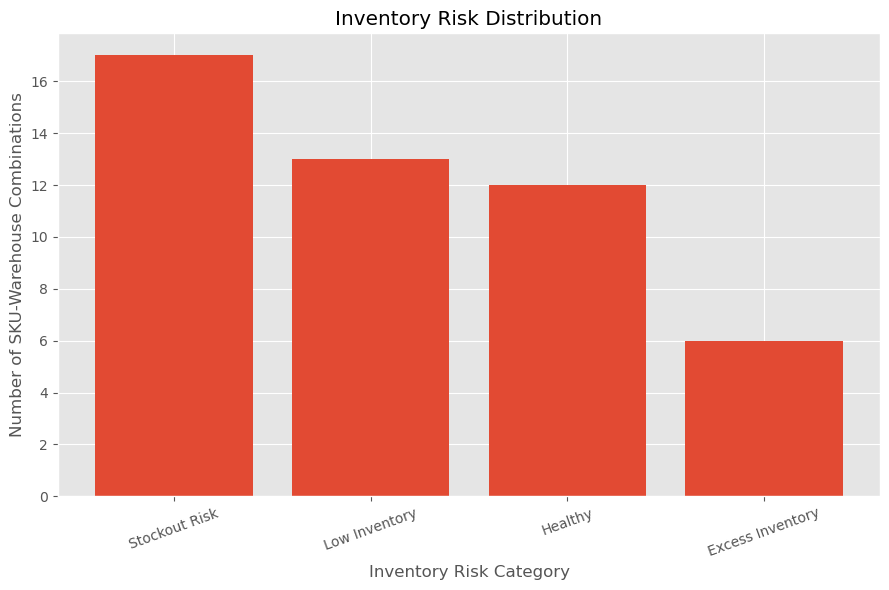

In [434]:
risk_counts = (
    inventory_base["inventory_risk"]
    .value_counts()
)

plt.figure(figsize=(9, 6))

plt.bar(
    risk_counts.index,
    risk_counts.values
)

plt.xlabel("Inventory Risk Category")
plt.ylabel("Number of SKU-Warehouse Combinations")
plt.title("Inventory Risk Distribution")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

In [435]:
warehouse_safety_stock = (
    inventory_base
    .groupby("warehouse_name")["safety_stock"]
    .sum()
    .sort_values(ascending=False)
)

warehouse_safety_stock

warehouse_name
West DC     7144.0
North DC    6010.0
South DC    4750.0
East DC     3944.0
Name: safety_stock, dtype: float64

In [436]:
warehouse_inventory_value = (
    inventory_base
    .groupby("warehouse_name")["inventory_value"]
    .sum()
    .sort_values(ascending=False)
)

warehouse_inventory_value

warehouse_name
West DC     2623290.0
North DC    2311730.0
South DC    1767420.0
East DC     1626450.0
Name: inventory_value, dtype: float64

In [437]:
inventory_kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Current Inventory Units",
        "Total Inventory Value",
        "Total Safety Stock Units",
        "Total Safety Stock Value",
        "Potential Excess Inventory Units",
        "Recommended Replenishment Units",
        "Stockout Risk Cases",
        "Low Inventory Cases",
        "Healthy Cases",
        "Excess Inventory Cases"
    ],

    "Value": [
        total_current_inventory,
        total_inventory_value,
        total_safety_stock,
        total_safety_stock_value,
        total_excess_inventory,
        total_recommended_replenishment,

        (
            inventory_base["inventory_risk"]
            == "Stockout Risk"
        ).sum(),

        (
            inventory_base["inventory_risk"]
            == "Low Inventory"
        ).sum(),

        (
            inventory_base["inventory_risk"]
            == "Healthy"
        ).sum(),

        (
            inventory_base["inventory_risk"]
            == "Excess Inventory"
        ).sum()
    ]
})

inventory_kpi_summary

,Metric,Value
0,Total Current Inventory Units,80699.0
1,Total Inventory Value,8328890.0
2,Total Safety Stock Units,21848.0
3,Total Safety Stock Value,2352120.0
4,Potential Excess Inventory Units,7448.0
5,Recommended Replenishment Units,9052.0
6,Stockout Risk Cases,17.0
7,Low Inventory Cases,13.0
8,Healthy Cases,12.0
9,Excess Inventory Cases,6.0


In [438]:
print(
    "========== DAY 9 INVENTORY OPTIMIZATION SUMMARY =========="
)

print("\nINVENTORY KPIs")

print(
    f"Current Inventory Units: "
    f"{total_current_inventory:.0f}"
)

print(
    f"Inventory Value: "
    f"{total_inventory_value:.2f}"
)

print(
    f"Safety Stock Units: "
    f"{total_safety_stock:.0f}"
)

print(
    f"Potential Excess Inventory: "
    f"{total_excess_inventory:.0f}"
)

print(
    f"Recommended Replenishment: "
    f"{total_recommended_replenishment:.0f}"
)

print("\nRISK DISTRIBUTION")

print(
    inventory_base["inventory_risk"]
    .value_counts()
)

print("\nBUSINESS INTERPRETATION")

print(
    "Safety stock protects against demand variability "
    "during replenishment lead time."
)

print(
    "The reorder point indicates when replenishment "
    "should be triggered."
)

print(
    "EOQ provides an illustrative order quantity that "
    "balances ordering and holding costs."
)

print(
    "The inventory policy identifies SKU-warehouse "
    "combinations requiring replenishment or attention."
)

========== DAY 9 INVENTORY OPTIMIZATION SUMMARY ==========

INVENTORY KPIs
Current Inventory Units: 80699
Inventory Value: 8328890.00
Safety Stock Units: 21848
Potential Excess Inventory: 7448
Recommended Replenishment: 9052

RISK DISTRIBUTION
inventory_risk
Stockout Risk       17
Low Inventory       13
Healthy             12
Excess Inventory     6
Name: count, dtype: int64

BUSINESS INTERPRETATION
Safety stock protects against demand variability during replenishment lead time.
The reorder point indicates when replenishment should be triggered.
EOQ provides an illustrative order quantity that balances ordering and holding costs.
The inventory policy identifies SKU-warehouse combinations requiring replenishment or attention.


In [439]:
# ============================================
# DAY 9 — INVENTORY OPTIMIZATION
# ============================================

import numpy as np
import pandas as pd

# Aggregate demand and inventory at SKU-Warehouse level
inventory_df = df.groupby(
    ['sku_id', 'sku_name', 'warehouse_id', 'warehouse_name']
).agg(
    avg_weekly_demand=('demand_units', 'mean'),
    weekly_demand_std=('demand_units', 'std'),
    avg_lead_time_days=('lead_time_days', 'mean'),
    unit_price=('unit_price', 'mean')
).reset_index()

# Fill missing standard deviation
inventory_df['weekly_demand_std'] = inventory_df['weekly_demand_std'].fillna(0)

# Convert weekly demand to daily demand
inventory_df['avg_daily_demand'] = inventory_df['avg_weekly_demand'] / 7

# Lead time in weeks
inventory_df['lead_time_weeks'] = inventory_df['avg_lead_time_days'] / 7

# 95% service level
z = 1.65

# Safety Stock
inventory_df['safety_stock'] = (
    z *
    inventory_df['weekly_demand_std'] *
    np.sqrt(inventory_df['lead_time_weeks'])
)

# Lead-time demand
inventory_df['lead_time_demand'] = (
    inventory_df['avg_weekly_demand'] *
    inventory_df['lead_time_weeks']
)

# Reorder Point
inventory_df['reorder_point'] = (
    inventory_df['lead_time_demand'] +
    inventory_df['safety_stock']
)

# Annual demand
inventory_df['annual_demand'] = (
    inventory_df['avg_weekly_demand'] * 52
)

# Illustrative EOQ assumptions
ordering_cost = 100
holding_rate = 0.20

inventory_df['annual_holding_cost_per_unit'] = (
    inventory_df['unit_price'] * holding_rate
)

# EOQ
inventory_df['eoq'] = np.sqrt(
    (
        2 *
        inventory_df['annual_demand'] *
        ordering_cost
    ) /
    inventory_df['annual_holding_cost_per_unit']
)

# Get latest available stock for each SKU-Warehouse
latest_stock = (
    df.sort_values('date')
      .groupby(['sku_id', 'warehouse_id'])
      .tail(1)
      [['sku_id', 'warehouse_id', 'available_stock_units']]
      .rename(columns={'available_stock_units': 'current_stock'})
)

# Merge current stock
inventory_df = inventory_df.merge(
    latest_stock,
    on=['sku_id', 'warehouse_id'],
    how='left'
)

# Inventory gap
inventory_df['inventory_gap'] = (
    inventory_df['current_stock'] -
    inventory_df['reorder_point']
)

# Reorder decision
inventory_df['reorder_flag'] = np.where(
    inventory_df['current_stock'] <= inventory_df['reorder_point'],
    'Reorder',
    'No Reorder'
)

# Recommended order quantity
inventory_df['recommended_order_qty'] = np.where(
    inventory_df['reorder_flag'] == 'Reorder',
    np.ceil(inventory_df['eoq']),
    0
)

# Inventory risk classification
inventory_df['risk_category'] = np.select(
    [
        inventory_df['current_stock'] <= inventory_df['reorder_point'],
        inventory_df['current_stock'] >
        inventory_df['reorder_point'] + inventory_df['eoq']
    ],
    [
        'Stockout Risk',
        'Excess Inventory'
    ],
    default='Healthy'
)

# Round numerical columns
numeric_cols = [
    'avg_weekly_demand',
    'weekly_demand_std',
    'avg_lead_time_days',
    'safety_stock',
    'lead_time_demand',
    'reorder_point',
    'annual_demand',
    'annual_holding_cost_per_unit',
    'eoq',
    'current_stock',
    'inventory_gap',
    'recommended_order_qty'
]

inventory_df[numeric_cols] = inventory_df[numeric_cols].round(2)

# Save policy table
inventory_df.to_csv(
    'inventory_optimization_policy.csv',
    index=False
)

# KPI summary
inventory_kpis = pd.DataFrame({
    'metric': [
        'Total SKU-Warehouse Combinations',
        'Stockout Risk Combinations',
        'Excess Inventory Combinations',
        'Healthy Combinations',
        'Total Recommended Order Quantity',
        'Average Reorder Point',
        'Average Safety Stock'
    ],
    'value': [
        len(inventory_df),
        (inventory_df['risk_category'] == 'Stockout Risk').sum(),
        (inventory_df['risk_category'] == 'Excess Inventory').sum(),
        (inventory_df['risk_category'] == 'Healthy').sum(),
        inventory_df['recommended_order_qty'].sum(),
        inventory_df['reorder_point'].mean(),
        inventory_df['safety_stock'].mean()
    ]
})

inventory_kpis.to_csv(
    'inventory_optimization_kpis.csv',
    index=False
)

print("DAY 9 COMPLETE")
print("Policy file:", 'inventory_optimization_policy.csv')
print("KPI file:", 'inventory_optimization_kpis.csv')

display(inventory_df.head())
display(inventory_kpis)

DAY 9 COMPLETE
Policy file: inventory_optimization_policy.csv
KPI file: inventory_optimization_kpis.csv


,sku_id,sku_name,warehouse_id,warehouse_name,avg_weekly_demand,weekly_demand_std,avg_lead_time_days,unit_price,avg_daily_demand,lead_time_weeks,...,lead_time_demand,reorder_point,annual_demand,annual_holding_cost_per_unit,eoq,current_stock,inventory_gap,reorder_flag,recommended_order_qty,risk_category
0,SKU01,Lager 650ml,WH01,North DC,2227.61,602.81,5.0,120.0,318.229396,0.714286,...,1591.15,2431.77,115835.5,24.0,982.49,3518,1086.23,No Reorder,0.0,Excess Inventory
1,SKU01,Lager 650ml,WH02,West DC,2485.23,710.04,5.0,120.0,355.032967,0.714286,...,1775.16,2765.32,129232.0,24.0,1037.75,4522,1756.68,No Reorder,0.0,Excess Inventory
2,SKU01,Lager 650ml,WH03,South DC,1714.13,481.68,5.0,120.0,244.876374,0.714286,...,1224.38,1896.08,89135.0,24.0,861.85,1522,-374.08,Reorder,862.0,Stockout Risk
3,SKU01,Lager 650ml,WH04,East DC,1412.92,389.90,5.0,120.0,201.846154,0.714286,...,1009.23,1552.95,73472.0,24.0,782.47,2899,1346.05,No Reorder,0.0,Excess Inventory
4,SKU02,Lager 330ml,WH01,North DC,2234.43,595.05,5.0,70.0,319.204670,0.714286,...,1596.02,2425.82,116190.5,14.0,1288.36,2705,279.18,No Reorder,0.0,Healthy


,metric,value
0,Total SKU-Warehouse Combinations,48.00000
1,Stockout Risk Combinations,17.00000
2,Excess Inventory Combinations,6.00000
3,Healthy Combinations,25.00000
4,Total Recommended Order Quantity,9026.00000
5,Average Reorder Point,1358.30125
6,Average Safety Stock,457.35750
